## **Librerias**


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "nbformat"])


CompletedProcess(args=['C:\\Users\\alexa\\AppData\\Local\\Microsoft\\WindowsApps\\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\\python.exe', '-m', 'pip', 'install', 'nbformat'], returncode=0)

## **Carga del dataset**

In [3]:
%run Cargar_datos.ipynb

C:\Users\alexa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


Dataset cargado: 10763 filas x 23 columnas


In [3]:
df = pd.read_excel('/content/BD_creditos (2).xlsx')

In [4]:
pd.options.display.max_columns =  None
pd.options.display.max_rows = None

In [5]:
df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,4,2025-01-07 14:40:36,1852560.0,12,32,Empleado,3500000,1000000,128650,95.227787,795.0,0,2,0.0,0.0,NaN,NaN,0,0,0,916148.0,Creciente,1
1,4,2025-01-09 11:18:48,3181080.0,6,34,Empleado,5000000,2000000,441817,95.227787,796.0,0,7,0.0,0.0,NaN,NaN,0,0,0,4473774.0,Creciente,1
2,9,2024-12-26 18:52:57,670200.0,5,34,Independiente,5000000,2000000,108632,95.227787,727.0,5,0,0.0,274561.0,274561.0,NaN,2,0,1,NaN,NaN,1
3,9,2024-12-04 14:20:50,506806.8,2,25,Independiente,3000000,900000,199684,95.227787,864.0,8,1,0.0,27564.0,27564.0,NaN,1,0,6,NaN,NaN,1
4,4,2025-04-30 18:41:57,999780.0,10,26,Empleado,2000000,600000,92509,95.227787,771.0,0,3,0.0,0.0,NaN,NaN,0,0,0,61000.0,Creciente,1


In [6]:
df.columns

Index(['tipo_credito', 'fecha_prestamo', 'capital_prestado', 'plazo_meses',
       'edad_cliente', 'tipo_laboral', 'salario_cliente',
       'total_otros_prestamos', 'cuota_pactada', 'puntaje',
       'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta',
       'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor',
       'creditos_sectorFinanciero', 'creditos_sectorCooperativo',
       'creditos_sectorReal', 'promedio_ingresos_datacredito',
       'tendencia_ingresos', 'Pago_atiempo'],
      dtype='str')

## **Exploración Inicial de los Datos**

### **Descripción general de los datos**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  int64         
 1   fecha_prestamo                 10763 non-null  datetime64[ns]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  object        
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  float64       
 11  cant_creditosvi

In [8]:
# ver los valores únicos de cada columna tipo object
for col in df.select_dtypes(include=['object']).columns:
    print(f"\nValores únicos de la columna {col}:")
    print(df[col].unique())


Valores únicos de la columna tipo_laboral:
['Empleado' 'Independiente']

Valores únicos de la columna tendencia_ingresos:
['Creciente' nan 'Estable' 'Decreciente' 8315 0 158042 3978 9147 168750
 -28589 1000000 -566272 24702 31837 122727 417087 9090 173031 -70715
 -435177 -702927 -4105 54683 22832 209090 5697 -288 -164315 2029000 17181
 15245 82657 52862 1817052 75761 146918 1123000 15090 4250635 22363
 -101368 86286 65988 77975 -224714 10808]


In [9]:
#ver valores únicos de columnas int:
for col in df.select_dtypes(include=['int64']).columns:
    print(f"\nValores únicos de la columna {col}:")
    print(df[col].unique())


Valores únicos de la columna tipo_credito:
[ 4  9 10  6  7 68]

Valores únicos de la columna plazo_meses:
[12  6  5  2 10  8 18  3  9 36 11 30 24  4 20  7 90 48]

Valores únicos de la columna edad_cliente:
[ 32  34  25  26  29  28  30  33  21  22  20  27  24  36  35  31  23  37
  62  56  57  46  42  39  43  40  54  55  52  61  58  38  48  49  41  60
  59  53  66  47  63  69  68  64  65  67  44  50  51  45  19 122 121 123]

Valores únicos de la columna salario_cliente:
[ 3500000  5000000  3000000 ...  1524547  3782303 10600000]

Valores únicos de la columna total_otros_prestamos:
[ 1000000  2000000   900000 ... 22005000   489000  2724000]

Valores únicos de la columna cuota_pactada:
[128650 441817 108632 ... 131953  59853  95233]

Valores únicos de la columna cant_creditosvigentes:
[ 0  5  8  7  2  3 10  9  6 13  4  1 12 21 18 22 20 11 19 17 16 14 24 15
 27 23 32 25 34 26 36 30 29 62 28 35 38 33 31]

Valores únicos de la columna huella_consulta:
[ 2  7  0  1  3  4  6  5 15  8 10  9 16 

  **Descripción de columnas**

* Variables del Crédito

  * `tipo credito`: Modalidad del crédito. Los códigos (4, 6, 7, 9, 10, 68) probablemente corresponden a clasificaciones internas(consumo, libre inversión, rotativo, etc.). Debe ser categórica nominal politómica.
  * `fecha_prestamo`: Fecha de desembolso del crédito. Variable tipo fecha.
  * `capital_prestado`: Monto en COP desembolsado al cliente. Numérica continua.
  * `plazo_meses`: Duración pactada del crédito en meses (van desde 2 hasta 90). Numérica Discreta.
  * `cuota_pactada`: Valor en COP de la cuota mensual acordada. Numércia Continua.

* Variables del Cliente

  * `edad_cliente`: Edad en años. Numérica discreta.
  * `tipo_laboral`: Condición laboral: Empleado o Independiente. Categórica nominal dicotómica.
  * `salario_cliente`: Ingreso mensual declarado en COP. Numérica continua.

* Variables de DataCredito/Comportamiento Crediticio

  * `puntaje`: Score crediticio interno de la entidad financiera. No es público ni estandarizado. Numérica continua.
  * `puntaje_datacredito`: Score externo de Datacrédito.Se expresa en una escala de 150 a 950 puntos: entre más alto el número, menor es la probabilidad estimada de incumplimiento. Numérica continua.
  * `promedio_ingresos_datacredito`: Ingreso promedio reportado por Datacrédito. Numérica continua.
  * `tendencia_ingresos`: Dirección del comportamiento de los ingresos del cliente según Datacrédito: Creciente, Estable o Decreciente. Categórica ordinal politómica.
  * `huella_consulta`: Número de veces que distintas entidades han consultado el historial crediticio de este cliente en Datacrédito. Numérica discreta.

* Variables de Endeudamiento

  * `total_otros_prestamos`: Saldo total en COP de otros créditos vigentes del cliente. Numérica continua.
  * `cant_creditosvigentes`: Número de obligaciones crediticias activas. Numérica discreta.
  * `creditos_sectorFinanciero`: Créditos activos en bancos, financieras vigiladas por Superfinanciera. Numérica discreta.
  * `creditos_sectorCooperativo`: Créditos en cooperativas (Coopcentral, Confiar, etc.). Numérica discreta.
  * `creditos_sectorReal`: Créditos con empresas del sector real (almacenes, concesionarios, etc.). Numérica discreta.

* Variables de Saldo y Mora

  * `saldo_total`: Saldo total pendiente del crédito en COP (incluyendo intereses). Numérica continua.
  * `saldo_principal`: Saldo de capital sin intereses. Numérica continua.
  * `saldo_mora`: Monto en COP en mora (vencido y no pagado). Numérica continua.
  * `saldo_mora_codeudor`: Mora reportada de un codeudor asociado al cliente. Numérica continua.

* Variable Objetivo:

* `Pago_atiempo`: 1 = pagó a tiempo, 0 = cayó en mora. Categórica Nominal dicotómica.



### **Unificación Nulos**

Antes de continuar, la variable tendencia_ingresos que es object tiene mezcla de strings y números, por lo que primero se hace NaN los valores numéricos, para poder hacer los análisis posteriores.

In [10]:
obj_cols = df.select_dtypes(include=['object']).columns
for columna in df[obj_cols].columns:
    print(df[columna].value_counts())

tipo_laboral
Empleado         6754
Independiente    4009
Name: count, dtype: int64
tendencia_ingresos
Creciente      5294
Decreciente    1291
Estable        1188
0                 7
8315              6
1000000           4
9147              2
158042            1
168750            1
3978              1
-28589            1
-566272           1
24702             1
31837             1
122727            1
417087            1
9090              1
173031            1
-70715            1
-435177           1
-702927           1
-4105             1
54683             1
22832             1
209090            1
5697              1
-288              1
-164315           1
2029000           1
17181             1
15245             1
82657             1
52862             1
1817052           1
75761             1
146918            1
1123000           1
15090             1
4250635           1
22363             1
-101368           1
86286             1
65988             1
77975             1
-224714           

In [11]:
# tendencia_ingresos tiene mezcla de strings y números: forzar NaN los numéricos
def limpiar_tendencia(valor):
    if valor in ["Creciente", "Estable", "Decreciente"]:
        return valor
    return np.nan  # cualquier valor numérico se convierte en nulo

df["tendencia_ingresos"] = df["tendencia_ingresos"].apply(limpiar_tendencia)

print("Valores únicos de tendencia_ingresos tras limpieza:")
print(df["tendencia_ingresos"].value_counts(dropna=False))

Valores únicos de tendencia_ingresos tras limpieza:
tendencia_ingresos
Creciente      5294
NaN            2990
Decreciente    1291
Estable        1188
Name: count, dtype: int64


In [12]:
df.isnull().sum()

,0
tipo_credito,0
fecha_prestamo,0
capital_prestado,0
plazo_meses,0
edad_cliente,0
tipo_laboral,0
salario_cliente,0
total_otros_prestamos,0
cuota_pactada,0
puntaje,0


In [13]:
#cantidad de 0 en variables numéricas
(df == 0).sum()

,0
tipo_credito,0
fecha_prestamo,0
capital_prestado,0
plazo_meses,0
edad_cliente,0
tipo_laboral,0
salario_cliente,24
total_otros_prestamos,445
cuota_pactada,0
puntaje,0


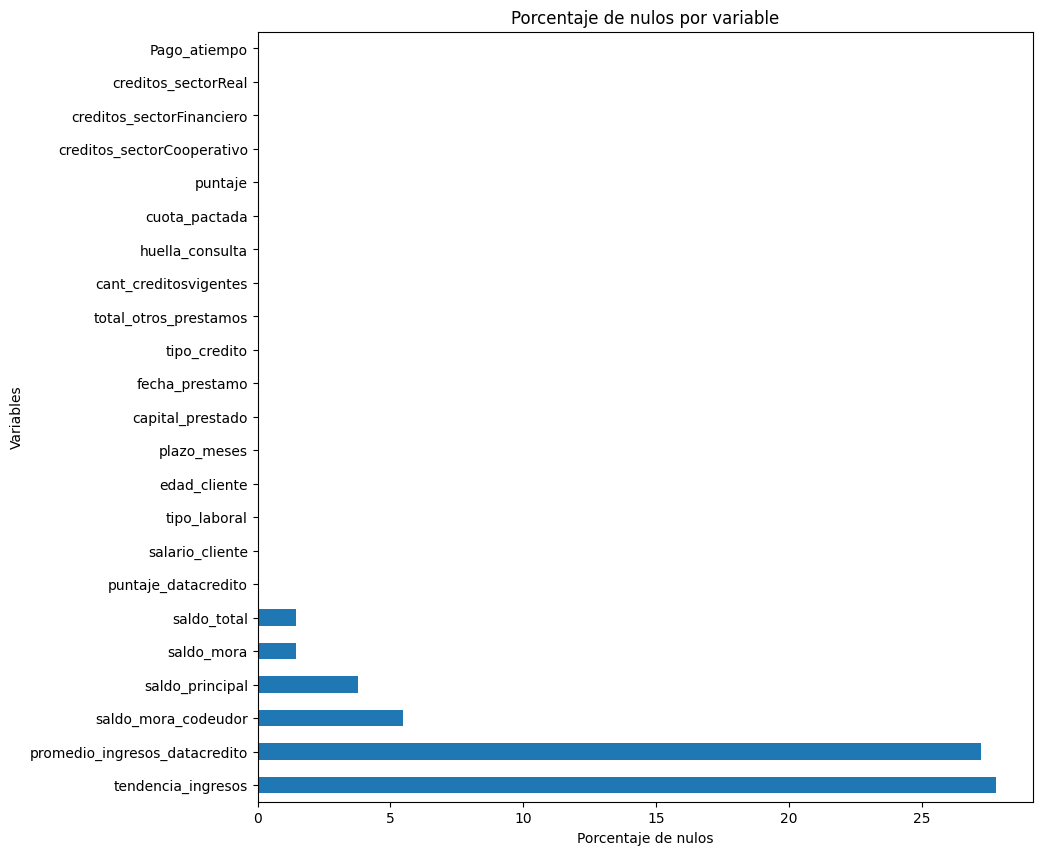

In [14]:
#Grafica del porcentaje de nulos por variable
(df.isnull().mean()*100).sort_values(ascending=False).plot(kind='barh', figsize=(10,10))
plt.title('Porcentaje de nulos por variable')
plt.xlabel('Porcentaje de nulos')
plt.ylabel('Variables')
plt.show()
#

Puede verse que: puntaje_datacredito tiene 6 nulos, saldo_mora y saldo_total tienen 156 nulos, saldo_principal tiene 405 nulos, saldo_mora_codeudor tiene 590 nulos, promedio_ingresos_datacredito tiene 2930 nulos y tendencia_ingresos tiene 2990 nulos.

Además, promedio_ingresos_datacredito y tendencia_ingresos tienen más del 15% de nulos, por lo que no pueden imputarse, hay que analizar si es mejor eliminar estas columnas.

Las demás variables con nulos si pueden imputarse, pero hay que analizar bien sus distribuciones para decidir que método es más apropiado usar. Ya que se trata de salarios, es probable que sea mejor usar knn.

In [15]:
# Valores que suelen representar nulos
valores_nulos_comunes = [
    '', ' ', 'NA', 'N/A', 'n/a', 'na',
    'NULL', 'null', 'None', 'none',
    '-', '--', '?', 'unknown', 'Unknown',
     -1, -999, -9999, 99999
]

for col in df.columns:
    # Buscar si hay valores sospechosos
    valores_raros = df[col].isin(valores_nulos_comunes).sum()

    if valores_raros > 0:
        print(f"\n  {col}:")
        print(f"   Encontrados {valores_raros} valores sospechosos")
        print(f"   Valores únicos: {df[col][df[col].isin(valores_nulos_comunes)].unique()}")
print("No se encontró nada")

No se encontró nada


Como puede verse, ya todos los nulos están en el mismo formato

### **Conversión de datos a su tipo correcto**

Con base en la caracterización realizada, se identificaron las siguientes conversiones necesarias:

* `tipo_credito` (int64 a category): aunque está codificada numéricamente, representa categorías nominales de productos crediticios, no una escala numérica.
* `tipo_laboral` (object a category): es una variable categórica dicotómica.
* `Pago_atiempo` (int64 a category): la variable objetivo es categórica nominal dicotómica (mora vs pago a tiempo), no una medida numérica.
* `tendencia_ingresos` (object a category ordered): es una variable categórica ordinal con jerarquía (Decreciente < Estable < Creciente).



* `salario_cliente` (int64 a float64): los salarios pueden incluir valores decimales.
* `cuota_pactada `(int64 a float64): las cuotas pueden tener decimales.
* `total_otros_prestamos` (int64 a float64): los saldos pueden contener cifras con decimales.

In [16]:
# Cambios a variables categóricas nominales
df["tipo_credito"] = df["tipo_credito"].astype("category")
df["tipo_laboral"] = df["tipo_laboral"].astype("category")
df["Pago_atiempo"] = df["Pago_atiempo"].astype("category")

#Cambiar a numéricas continuas
df["salario_cliente"] = df["salario_cliente"].astype(float)
df["cuota_pactada"] = df["cuota_pactada"].astype(float)
df["total_otros_prestamos"] = df["total_otros_prestamos"].astype(float)

#Cambiar a ordinal politómica
from pandas.api.types import CategoricalDtype
orden_tend_ingresos = CategoricalDtype(
    categories=["Decreciente", "Estable", "Creciente"],
    ordered=True
)
df["tendencia_ingresos"] = df["tendencia_ingresos"].astype(orden_tend_ingresos)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  category      
 1   fecha_prestamo                 10763 non-null  datetime64[ns]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  category      
 6   salario_cliente                10763 non-null  float64       
 7   total_otros_prestamos          10763 non-null  float64       
 8   cuota_pactada                  10763 non-null  float64       
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  float64       
 11  cant_creditosvi

### **Eliminación de variables irrelevantes**

#### **Correlación con la variable objetivo**

Se calculó la correlación de Pearson entre todas las variables numéricas y `Pago_atiempo`

In [18]:
df.corrwith(df['Pago_atiempo'],method='pearson', numeric_only=True)


,0
capital_prestado,-0.040624
plazo_meses,-0.063105
edad_cliente,0.032252
salario_cliente,-0.003981
total_otros_prestamos,-0.010041
cuota_pactada,-0.011814
puntaje,0.923134
puntaje_datacredito,0.067882
cant_creditosvigentes,0.008829
huella_consulta,-0.073737


**Hallazgos principales:**

- **`puntaje` (0.923)**: Presenta una correlación muy fuerte con la variable objetivo. Puede deberse a que se calculó después de que el cliente pagara.

#### **Correlación entre variables numéricas**

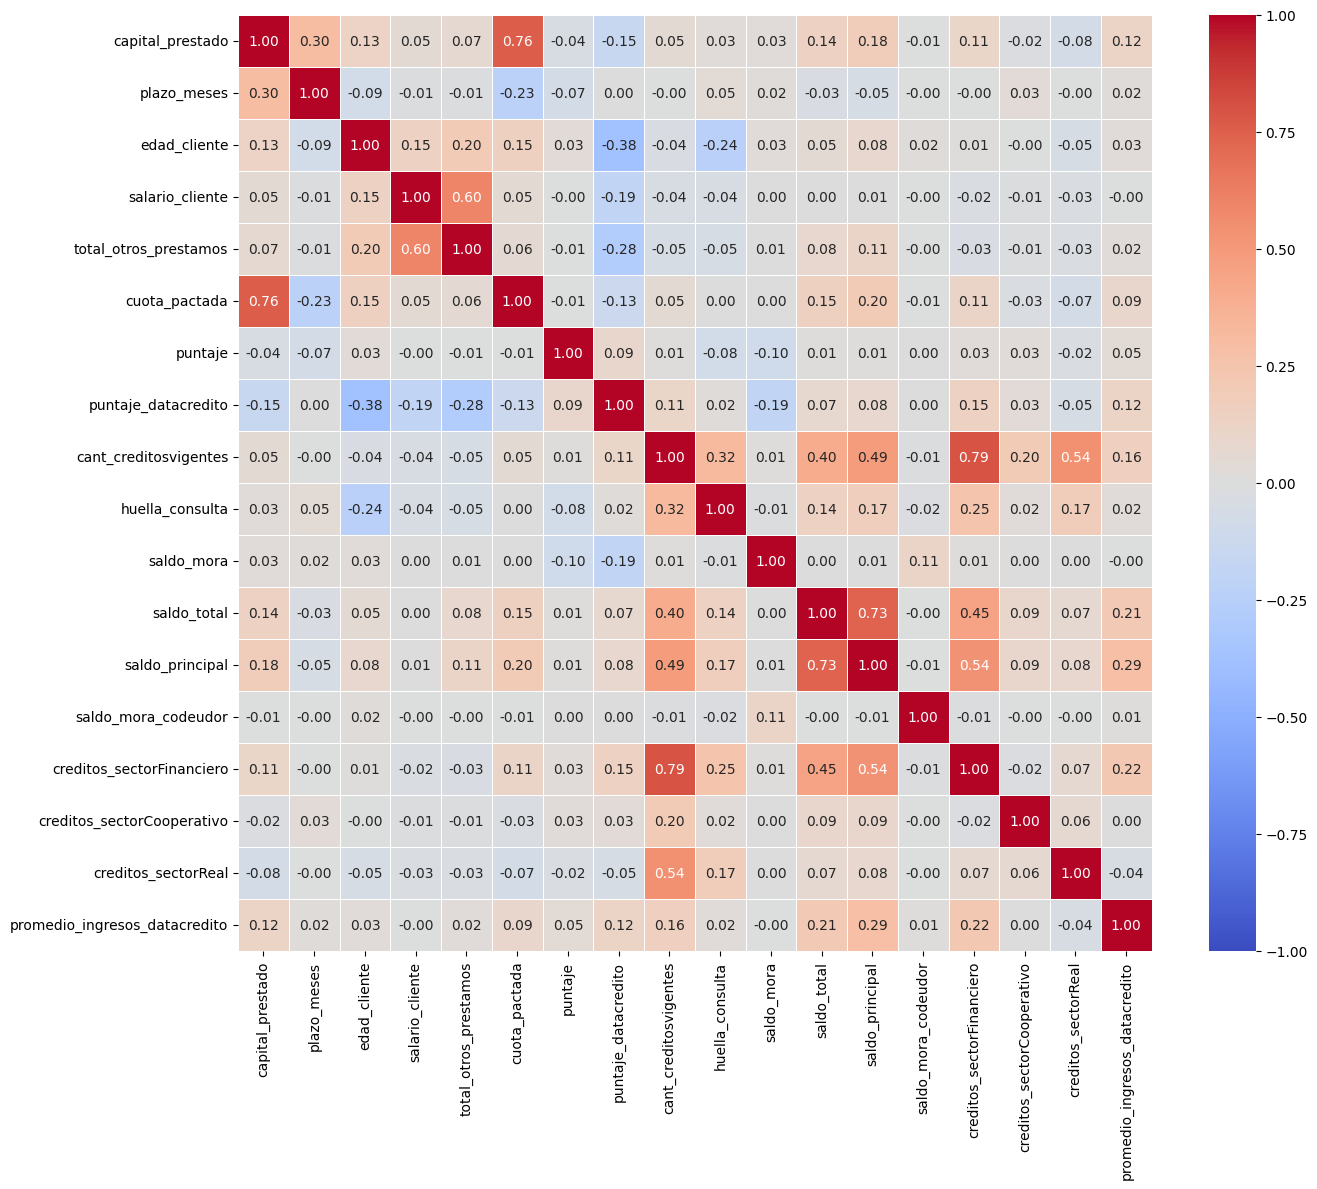

In [19]:
#Matriz de correlación
corr = df.corr(method='pearson', numeric_only=True)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, ax=ax, annot=True, fmt=".2f",
            xticklabels=True, yticklabels=True,
            cmap="coolwarm", linewidths=.5,
            vmin=-1, vmax=1)

ax.tick_params(axis='x', rotation=90)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

**Hallazgos principales:**

* `cant_creditosvigentes` y `creditos_sectorFinanciero`:
Alta correlación, de **0.79**. Tiene sentido ya que usualmente, la mayoría de créditos vienen de bancos/financieras.

* `saldo_total` y `saldo_principal`:
Alta correlación, de **0.73**. Lógico, ya que ya que el saldo total incluye el saldo de capital más los intereses devengados.

* `capital_prestado` y `cuota_pactada`:
Alta correlación, de **0.76**. A mayor capital prestado, mayor cuota mensual, tiene sentido.

* `saldo_mora_codeudor`: Tiene correlaciones prácticamente nulas  con todas las variables, incluyendo la variable objetivo.

En base en esto y la cantidad de nulos, se decide eliminar:

- **`promedio_ingresos_datacredito`** (27.22% nulos): No es posible imputar de forma confiable casi un tercio de los datos.

- **`tendencia_ingresos`** (27.78% nulos): Alta proporción de valores faltantes tras la limpieza de datos incorrectos.

- **`puntaje`** (correlación 0.923 con `Pago_atiempo`): Correlación muy alta. Posibilidad de que haya sido calculado después del pago.

- **`fecha_prestamo`** : Se considera que no hay razón de negocio por la cual créditos de una fecha específica tengan sistemáticamente mayor riesgo. Aunque podrían encontrarse patrones estacionales (por ejemplo, mayor mora en créditos desembolsados en diciembre por gastos navideños o menos mora en épocas de pago de prima).

- **`cant_creditosvigentes`** (correlación 0.79 con `creditos_sectorFinanciero`): Altamente correlacionada con los créditos del sector financiero, y se elimina esta porque las variables de crédito por sector podrían aportar más información.

- **`saldo_principal`** (correlación 0.73 con `saldo_total`, 3.76% nulos): Se conserva `saldo_total` por ser más completo (incluye lo de saldo principal) y por tener menos nulos.

- **`cuota_pactada`** (correlación 0.76 con `capital_prestado`): Se elimina para reducir multicolinealidad, considerando que el capital prestado ya captura la exposición al riesgo y el plazo ya existe como variable independiente. Además el pago mensual puede inferirse indirectamente de la combinación capital + plazo.

In [20]:

df = df.drop(columns=['promedio_ingresos_datacredito', 'tendencia_ingresos','fecha_prestamo','puntaje','cuota_pactada','saldo_principal','cant_creditosvigentes'])


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   tipo_credito                10763 non-null  category
 1   capital_prestado            10763 non-null  float64 
 2   plazo_meses                 10763 non-null  int64   
 3   edad_cliente                10763 non-null  int64   
 4   tipo_laboral                10763 non-null  category
 5   salario_cliente             10763 non-null  float64 
 6   total_otros_prestamos       10763 non-null  float64 
 7   puntaje_datacredito         10757 non-null  float64 
 8   huella_consulta             10763 non-null  int64   
 9   saldo_mora                  10607 non-null  float64 
 10  saldo_total                 10607 non-null  float64 
 11  saldo_mora_codeudor         10173 non-null  float64 
 12  creditos_sectorFinanciero   10763 non-null  int64   
 13  creditos_sectorC

## **EDA**

### **Análisis univariable**

#### **Estadisticas Generales**

In [22]:
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
tipo_credito,10763.0,6.0,4.0,7747.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
capital_prestado,10763.0,NaN,NaN,NaN,2434315.001319,1909642.758997,360000.0,1224831.0,1921920.0,3084840.0,41444152.8
plazo_meses,10763.0,NaN,NaN,NaN,10.575583,6.632082,2.0,6.0,10.0,12.0,90.0
edad_cliente,10763.0,NaN,NaN,NaN,43.94862,15.060877,19.0,33.0,42.0,53.0,123.0
tipo_laboral,10763,2,Empleado,6754,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salario_cliente,10763.0,NaN,NaN,NaN,17216431.459909,355476717.60349,0.0,2000000.0,3000000.0,4875808.0,22000000000.0
total_otros_prestamos,10763.0,NaN,NaN,NaN,6238869.648518,118418316.941069,0.0,500000.0,1000000.0,2000000.0,6787675263.0
puntaje_datacredito,10757.0,NaN,NaN,NaN,780.790834,104.878031,-7.0,757.0,791.0,825.0,999.0
huella_consulta,10763.0,NaN,NaN,NaN,4.228561,3.064683,0.0,2.0,4.0,6.0,29.0
saldo_mora,10607.0,NaN,NaN,NaN,7.746017,225.955117,0.0,0.0,0.0,0.0,12534.0


In [23]:
df.describe(include='category')

,tipo_credito,tipo_laboral,Pago_atiempo
count,10763,10763,10763
unique,6,2,2
top,4,Empleado,1
freq,7747,6754,10252


**Insights**

* En promedio los clientes prestan 2.4M, pagan en 10 meses, tienen más de 40 años, tienen un puntaje de 781 en datacredito (lo cual es bastante alto), y tienen más créditos en el sector financiero.

* La desviación estandar del capital_prestado es extremadamente alta, ya que puede verse que se están juntado microcréditos con grandes créditos (el mínimo es de 360.000 y el máximo es de 41M). La mayoría de los créditos desembolsados son de montos pequeños: el 75% es ≤$3M COP (Q3), con una mediana de 1.9M.

* La edad mínima parece correcta ya que es de 19, es decir que ya son mayores de edad, sin embargo la edad máxima parece un dato incorrecto (123 años). No muchos de los que piden créditos son muy jovenes, ya que el 75% de los clientes tiene 33 o más.

* La desviación estandar del salario del cliente es muy alta, lo cual puede deberse a que hay un máximo muy alto (22.000.000.000), sin embargo solo el 25% de los clientes gana más de 4.8M.

* La mayoría de clientes son Empleados (más de la mitad).

* La desviación estandar de total otros prestamos también es muy alta porque hay clientes que deben mucho y unos que no deben nada de otros préstamos. El 75% de los clientes tiene un endeudamiento previo ≤$2M COP en otras entidades (no están muy endeudados).

* Parecen haber outliers en el puntaje de datacredito ya que se deben encontrar en el rango de 150-950, el 75% de los clientes tiene un puntaje igual o mayor a 757 (alto)

* Solo el 25% de los clientes tiene 6 o más consultas en Datacrédito (huella de consulta alta), lo que indica que a la mayoría no los buscan mucho.

* La mayoria de clientes no tienen saldo en mora.

* La mayoria de clientes no tienen créditos en cooperativas, pero el 75% de los clientes tiene 1 o más créditos en el sector financiero.

* El tipo de crédito más frecuente es el 4 ( con más de la mitad).

* La mayoria de clientes pagan a tiempo (aproximadamente el 95%). Está bastante desbalanceado.

#### **Variables numéricas**

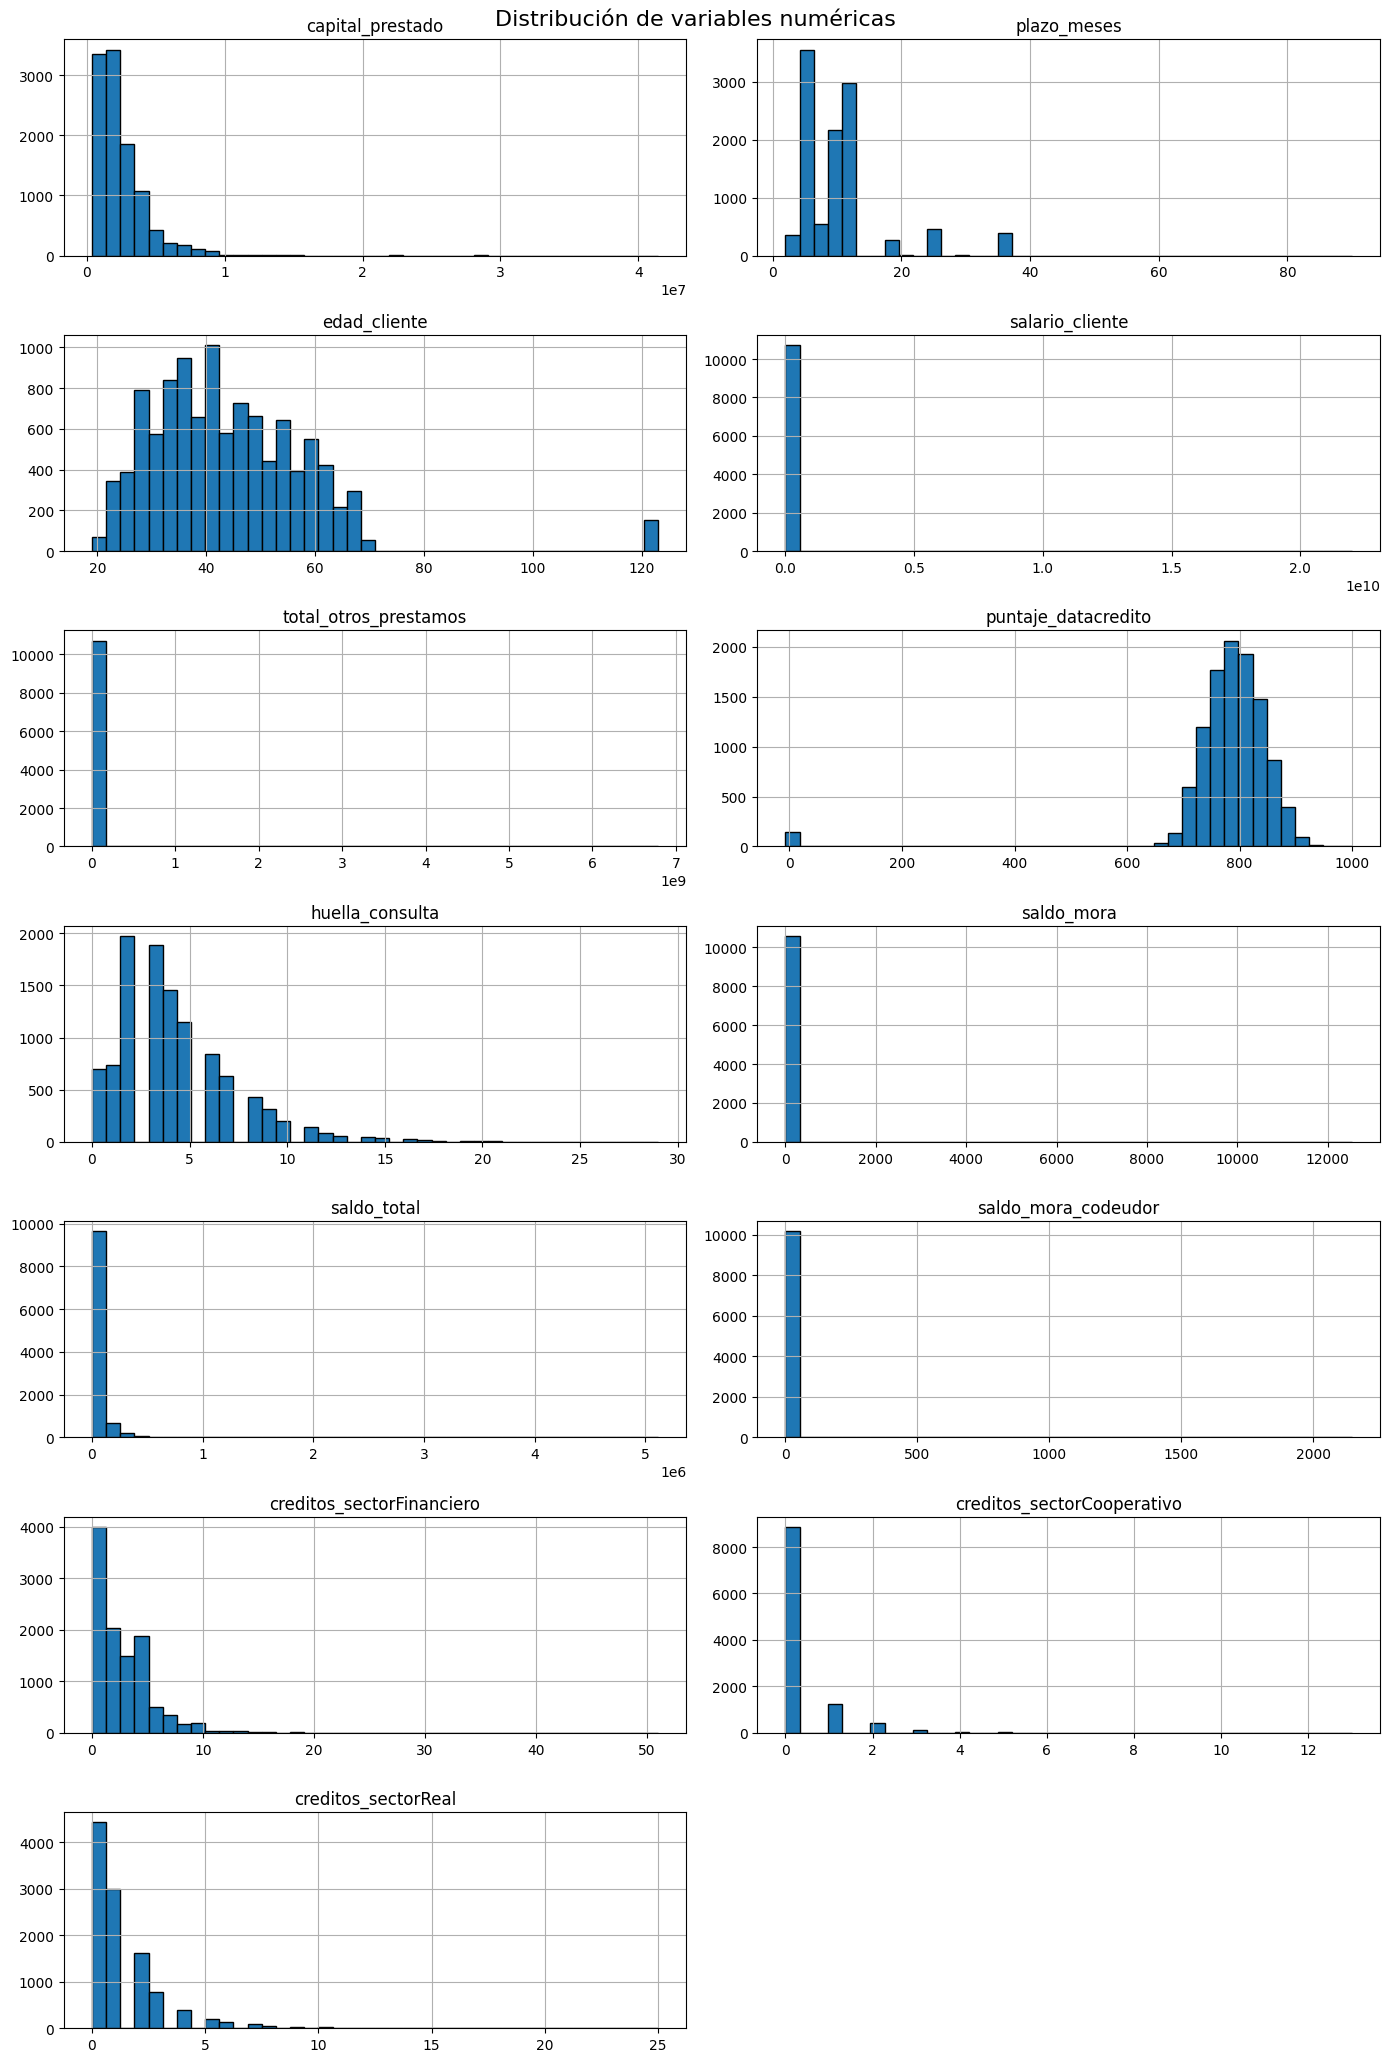

In [24]:
n_vars = len(df.select_dtypes(include=np.number).columns)
n_cols = 2
n_rows = int(np.ceil(n_vars / n_cols))

df.select_dtypes(include=np.number).hist(
    figsize=(14, n_rows * 3),  # Altura dinámica según número de filas
    bins=40,
    layout=(n_rows, n_cols),
    edgecolor='black'
)
plt.suptitle('Distribución de variables numéricas', fontsize=16)
plt.tight_layout()
plt.show()

Hay algunas variables donde no se aprecia bien la distribución ya que hay valores muy extremos, así que se grafican usando datos hasta el percentil 99.

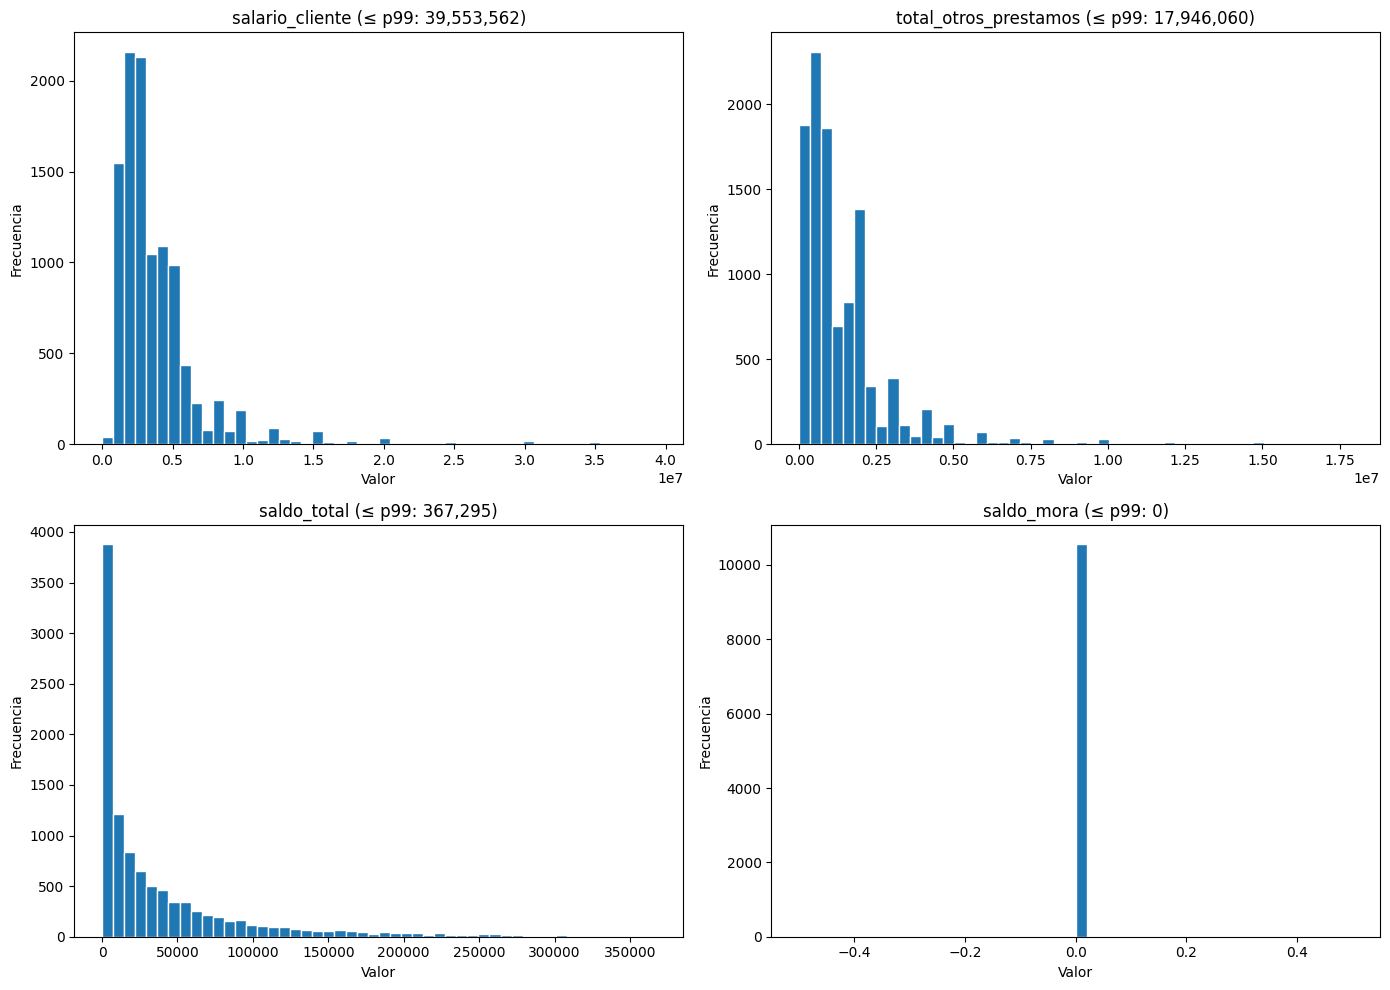

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cols = ['salario_cliente', 'total_otros_prestamos', 'saldo_total', 'saldo_mora']

for ax, col in zip(axes.flatten(), cols):
    data = df[col].dropna()
    p99 = data.quantile(0.99)
    data_clipped = data[data <= p99]
    ax.hist(data_clipped, bins=50, edgecolor='white')
    ax.set_title(f'{col} (≤ p99: {p99:,.0f})')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

**Sesgadas a la derecha** (cola larga hacia valores altos): la mayoría de los datos se concentran en valores bajos.

* capital_prestado, salario_cliente, total_otros_prestamos, saldo_total, saldo_mora, saldo_mora_codeudor, creditos_sectorFinanciero, creditos_sectorCooperativo y creditos_sectorReal

Esto es normal en todas estas variables y confirma lo que se vio en las estadísticas generales:

la mayoría de personas piden créditos de montos pequeños, tienen salarios bajos o moderados, pocos compromisos financieros vigentes y saldos en mora cercanos a cero. Los valores extremos
corresponden a casos atípicos de clientes con alta capacidad económica o alto endeudamiento.

**Aproximadamente normales o simétricas**: se distribuyen de forma relativamente equilibrada alrededor de su valor central:

* puntaje_datacredito: El puntaje de Datacredito se concentra alrededor de 780–791 (media y mediana muy cercanas), lo que indica que la mayoría de los solicitantes tienen un historial crediticio aceptable.

* edad_cliente: distribución relativamente uniforme entre 30 y 55 años, con un bin cerca de 120.

**Distribuciones discretas**: toman valores enteros y con frecuencias muy concentradas en valores bajos:


* plazo_meses, huella_consulta, creditos_sectorFinanciero, creditos_sectorCooperativo, creditos_sectorReal

La mayoría de los créditos tienen plazos cortos (mediana 10 meses), pocos registros de consultas en centrales de riesgo y un número reducido de créditos activos en otros sectores.





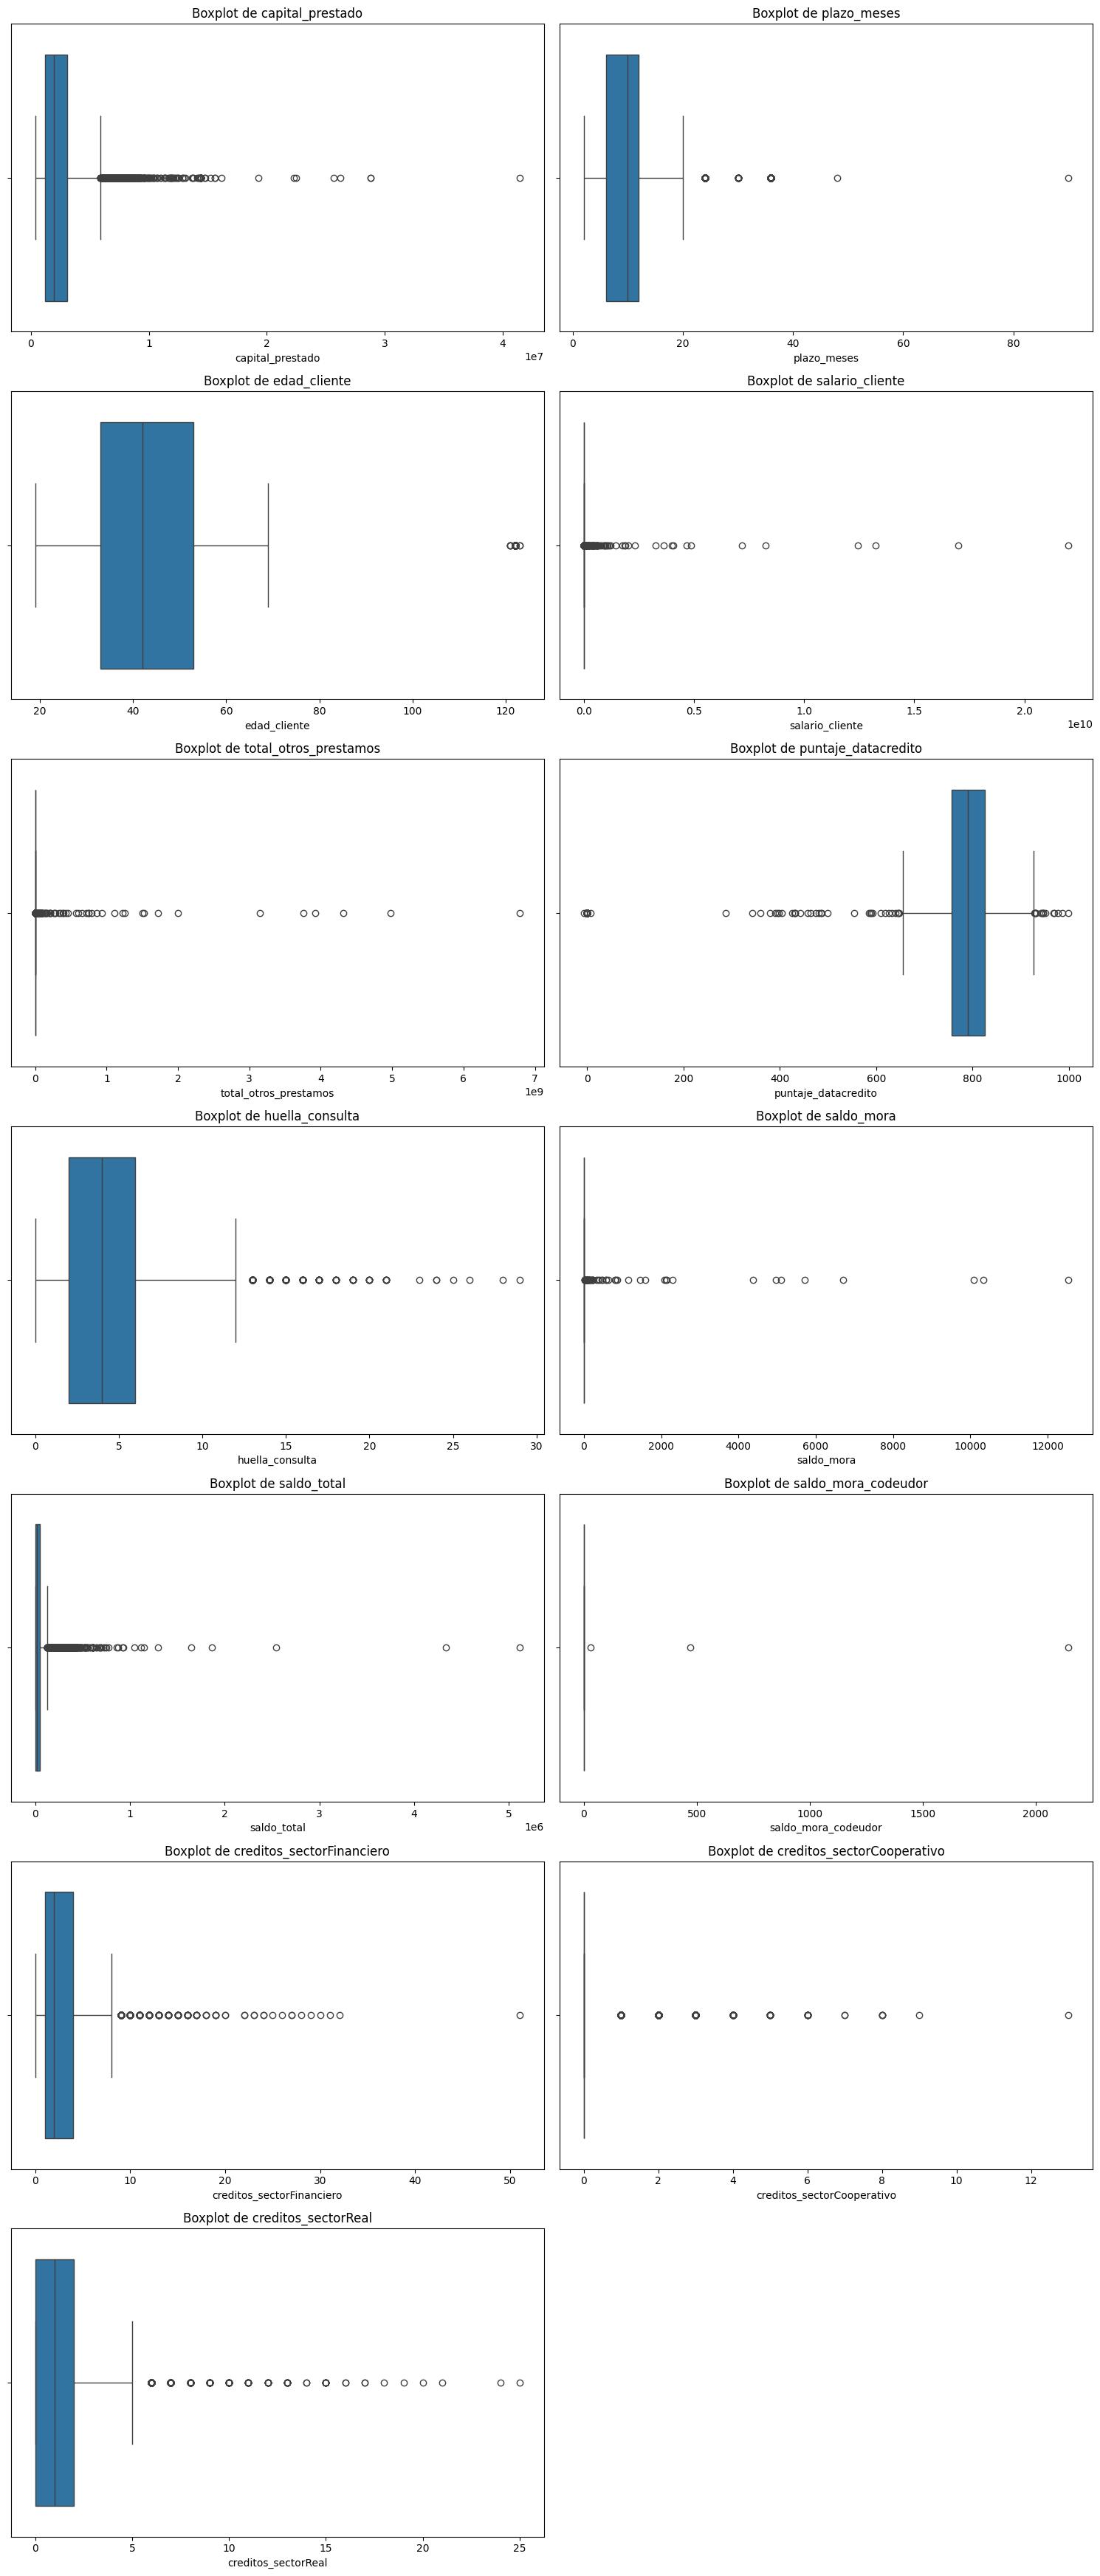

In [26]:
num_cols = df.select_dtypes(include=np.number).columns

n_rows = int(np.ceil(len(num_cols) / 2))

plt.figure(figsize=(15, 5 * n_rows))
for i,col in enumerate(num_cols):
  plt.subplot(n_rows, 2, i+1)
  sns.boxplot(x=df[col])
  plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

In [27]:
#ver registros donde el capital prestado sea mayor a 30 millones para analizar si son el mismo tipo de crédito
df[df['capital_prestado'] > 20000000]

,tipo_credito,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,puntaje_datacredito,huella_consulta,saldo_mora,saldo_total,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,Pago_atiempo
4784,4,22502400.0,8,41,Empleado,0.0,0.0,877.0,12,0.0,484531.0,0.0,5,4,2,1
5668,9,28800000.0,12,52,Empleado,19000000.0,12000000.0,819.0,8,0.0,19.0,0.0,1,0,0,1
10494,9,26208019.2,10,123,Empleado,119728880.0,7630074.0,0.0,0,NaN,NaN,NaN,0,0,0,1
10559,9,22261135.2,10,122,Empleado,71000000.0,68000000.0,0.0,0,NaN,NaN,NaN,0,0,0,1
10569,9,25657455.6,10,122,Empleado,129000000.0,84000000.0,0.0,0,NaN,NaN,NaN,0,0,0,1
10570,9,28779582.0,11,122,Empleado,90107306.0,68835601.0,0.0,0,NaN,NaN,NaN,0,0,0,1
10595,9,41444152.8,10,122,Empleado,92564739.0,51522111.0,0.0,0,NaN,NaN,NaN,0,0,0,1


Los boxplots confirman lo visto en los histogramas:

* capital_prestado, salario_cliente, total_otros_prestamos, saldo_total, saldo_mora, saldo_mora_codeudor, creditos_sectorFinanciero, creditos_sectorCooperativo, creditos_sectorReal:

cajas muy comprimidas hacia valores bajos con numerosos outliers hacia la derecha, confirmando el fuerte sesgo de estas variables.

* puntaje_datacredito: es la única variable con comportamiento inverso, la caja está ubicada en valores altos y los outliers aparecen hacia la izquierda, correspondiendo a clientes con historial crediticio deficiente. Deben analizarse outliers ya que el puntaje empieza en 150 y termina en 950.

* edad_cliente: caja amplia y bien distribuida entre los 30 y 55 años, con outliers cerca de 120 que si pueden deberse a datos erroneos

* plazo_meses y huella_consulta: cajas pequeñas concentradas en valores bajos con algunos outliers puntuales, coherente con que la mayoría de créditos son de corto plazo y los clientes tienen pocas consultas registradas.

Además, basado en esto, las reglas de validación más relevantes podrían ser:

* `edad_cliente`: debe estar entre 18 y 100 años (incluso podría analizarse si es mejor bajarlo a 90 años)
* `puntaje_datacredito`: debe estar entre 150 y 950.El valor -7 encontrado es inválido y los 6 nulos o valores fuera del rango deberán imputarse o excluirse.
* `salario_cliente`: debe ser mayor a 0, los registros con salario 0 son sospechosos y deberían revisarse antes de modelar (ya que todas las personas son empleados o independientes, no hay categoría de desempleado)
* `capital_prestado`: sin tener información del monto máximo y mínimo que presta el banco y los tipos de crédito que ofrece, es difícil establecer límites precisos, pero con base en las estadísticas y el boxplot se podría poner el mínimo en 300,000 y el máximo en 50,000,000 (los valores que superan los 30M posiblemente son créditos hipotecarios).
* `plazo_meses`: debe estar entre 1 y 90 meses.



#### **Variables categóricas**

In [28]:
cat_cols = df.select_dtypes(include= 'category').columns
for col in cat_cols:
  print(f'Columna: {col}')
  print(df[col].value_counts(dropna=False))

Columna: tipo_credito
tipo_credito
4     7747
9     2876
10     116
6       21
7        2
68       1
Name: count, dtype: int64
Columna: tipo_laboral
tipo_laboral
Empleado         6754
Independiente    4009
Name: count, dtype: int64
Columna: Pago_atiempo
Pago_atiempo
1    10252
0      511
Name: count, dtype: int64


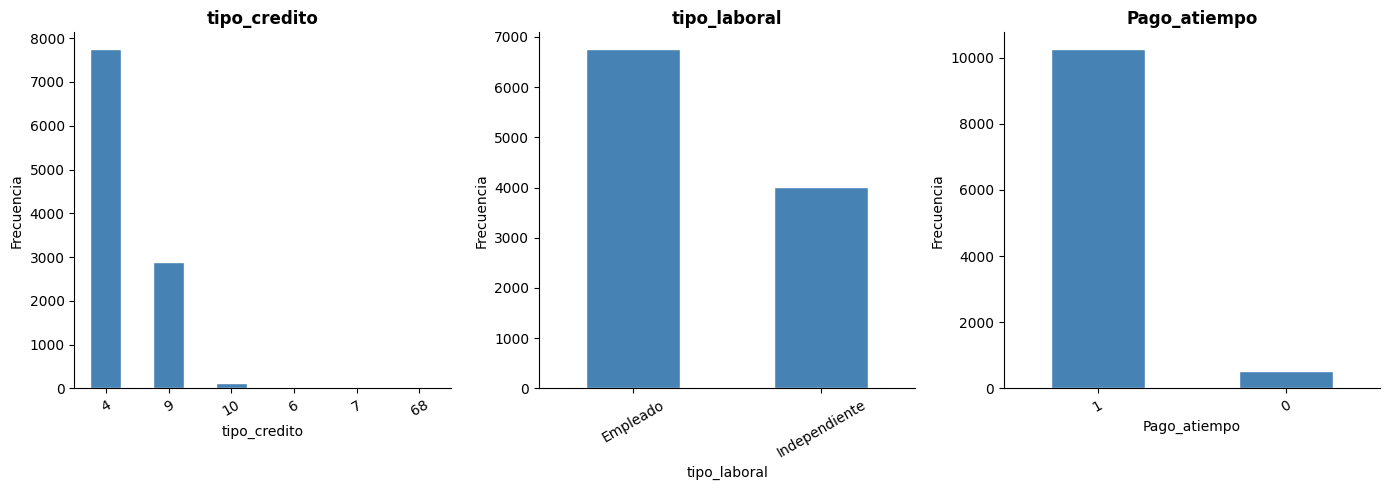

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col in zip(axes, ['tipo_credito', 'tipo_laboral', 'Pago_atiempo']):
    df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=30)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Se puede ver lo que ya se analizó en las estadísticas generales:

* `tipo_credito`: la mayoria son del tipo 4, y los tipos 6, 7 y 68
  tienen presencia muy pequeña.

* `tipo_laboral`: predominan los clientes con empleo formal.

* `Pago_atiempo`:  El dataset está fuertemente desbalanceado,
  lo cual deberá considerarse en la etapa de modelamiento.

### **Análisis bivariable respecto a la variable objetivo Pago_atiempo**

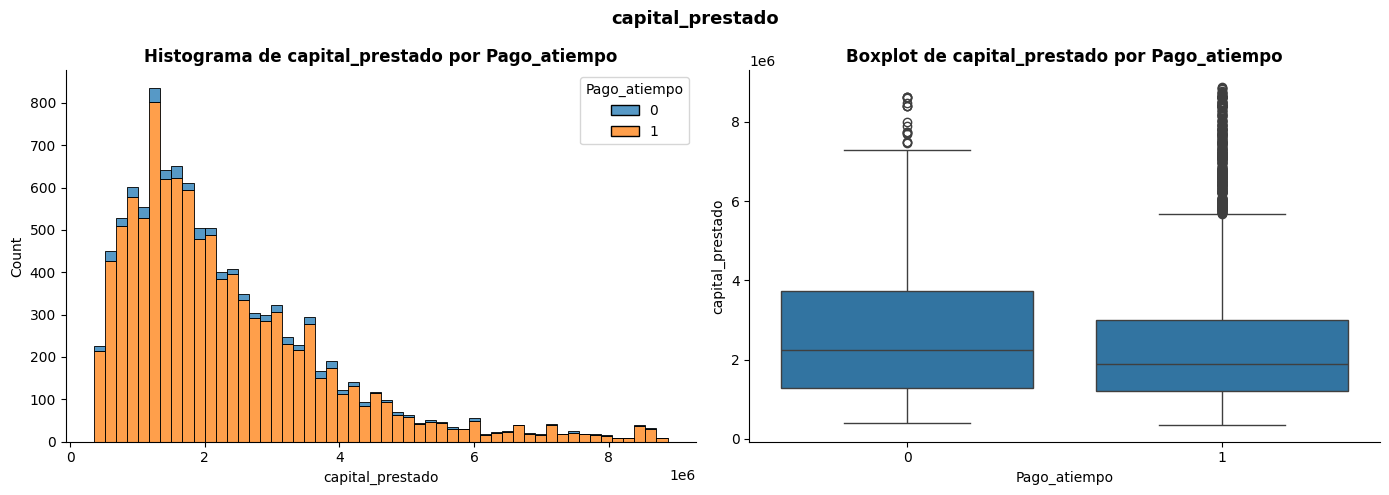

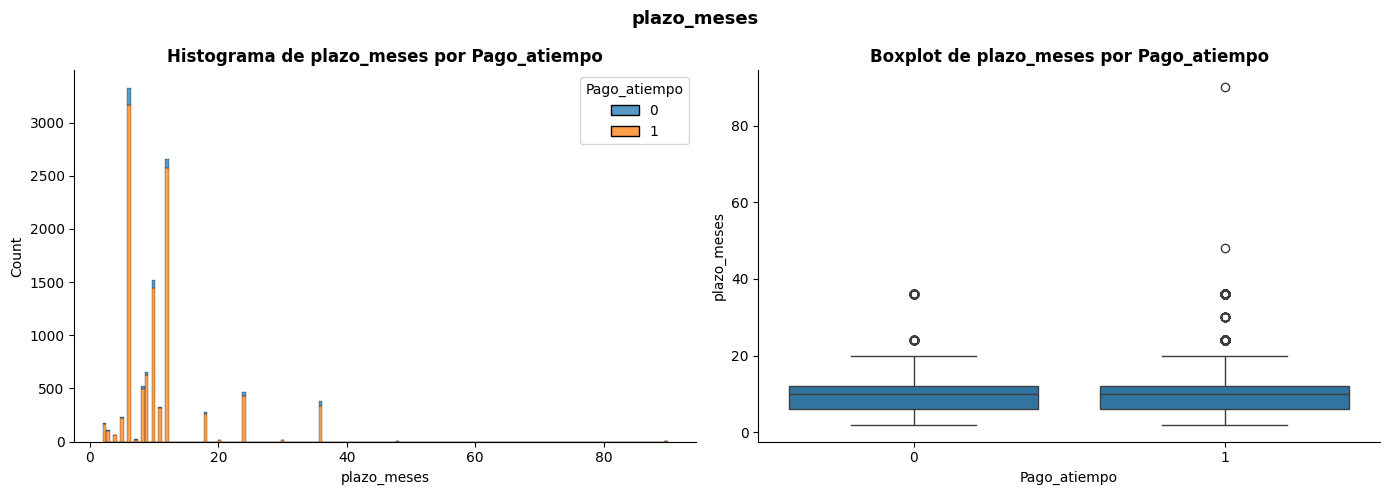

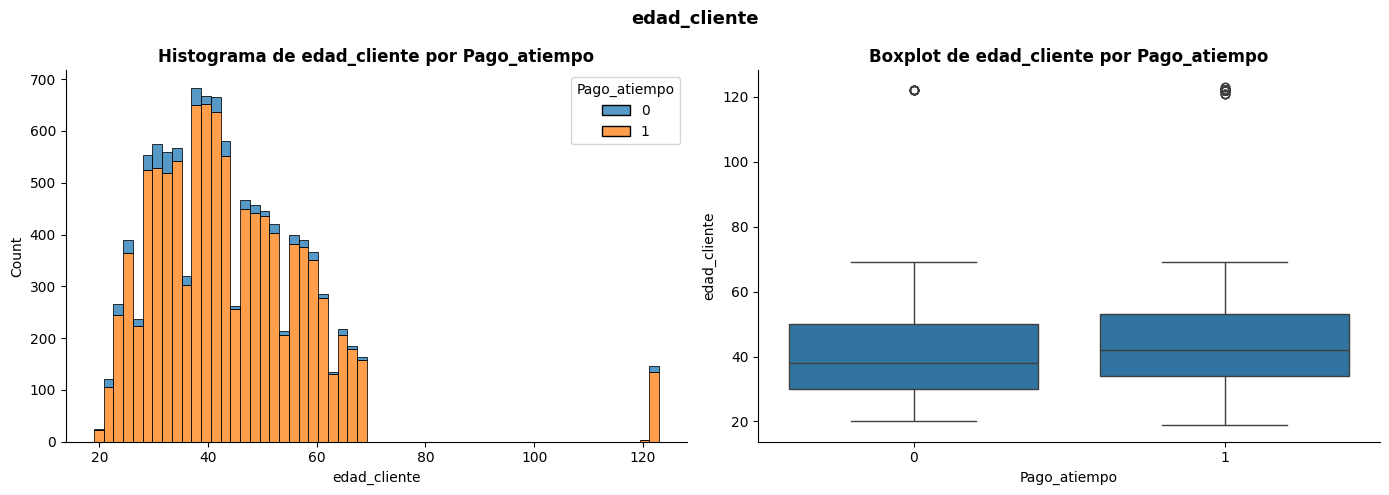

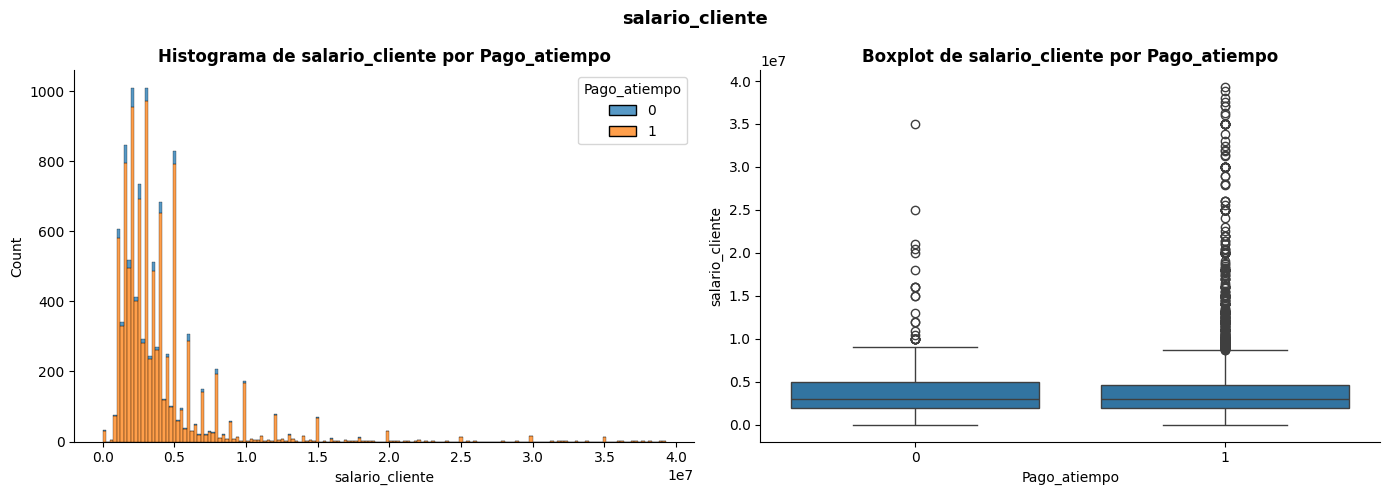

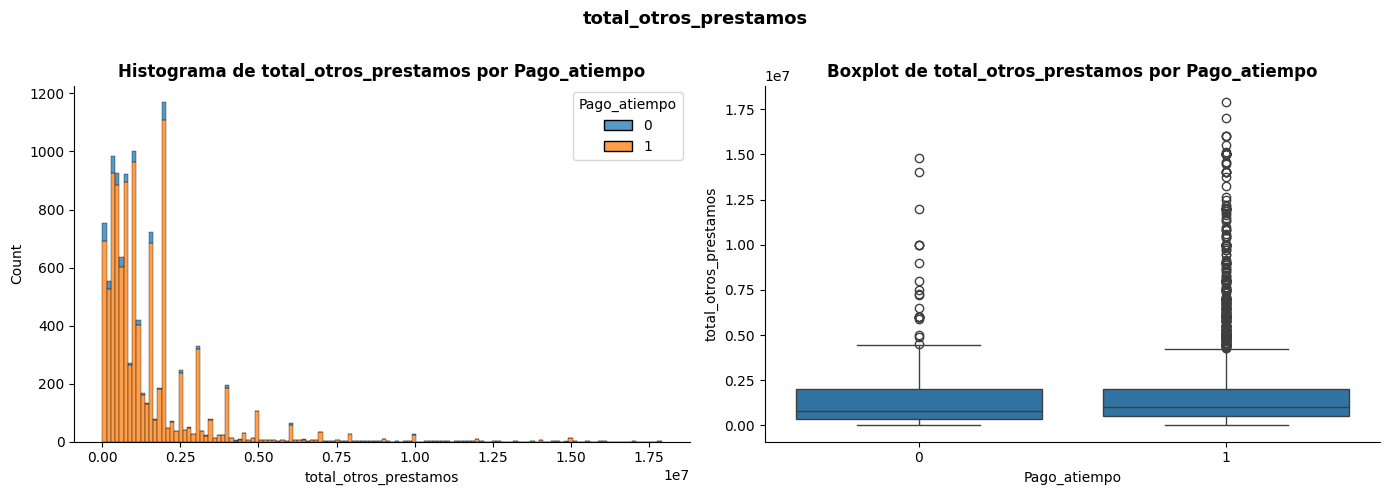

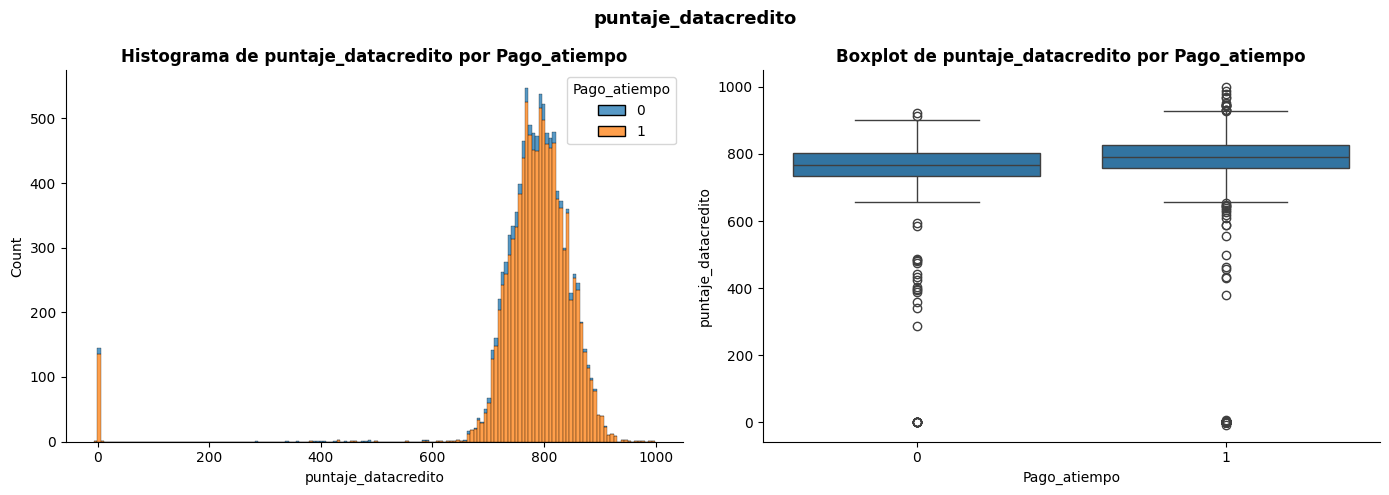

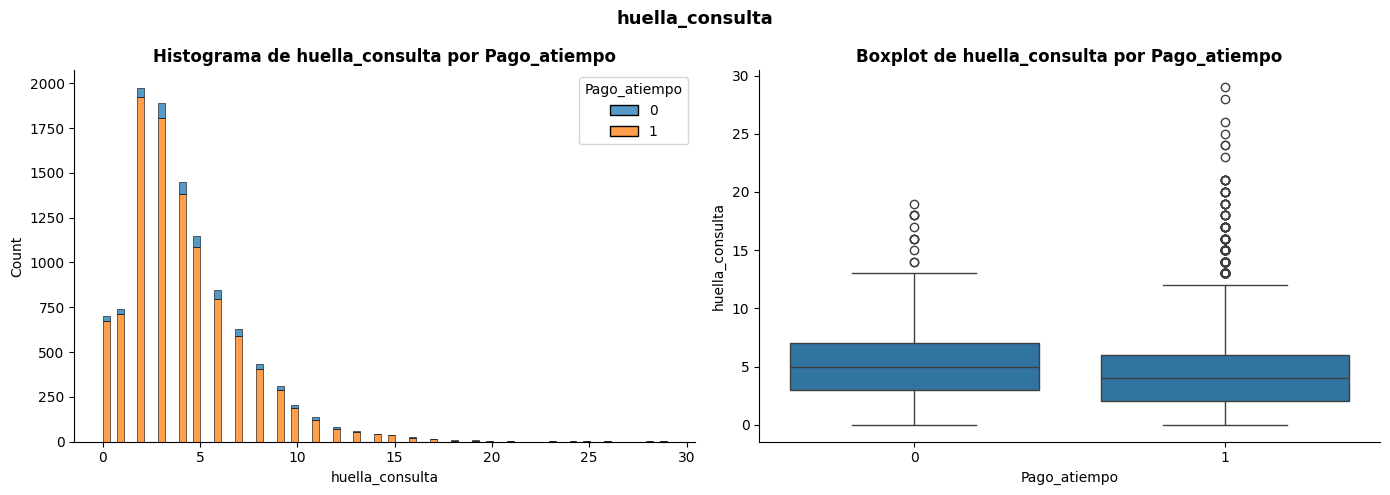

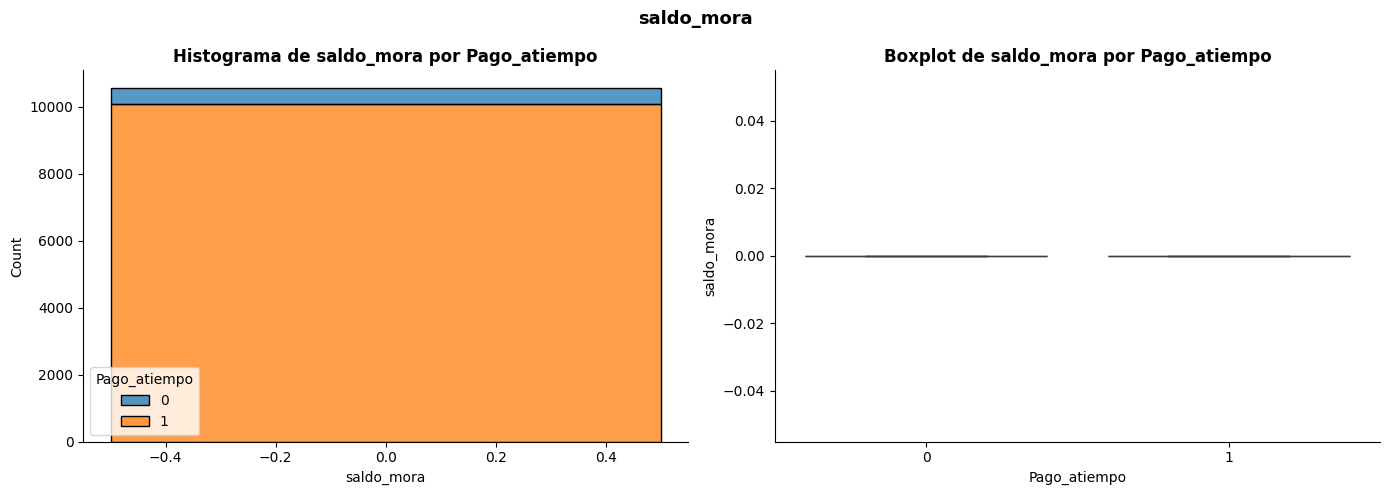

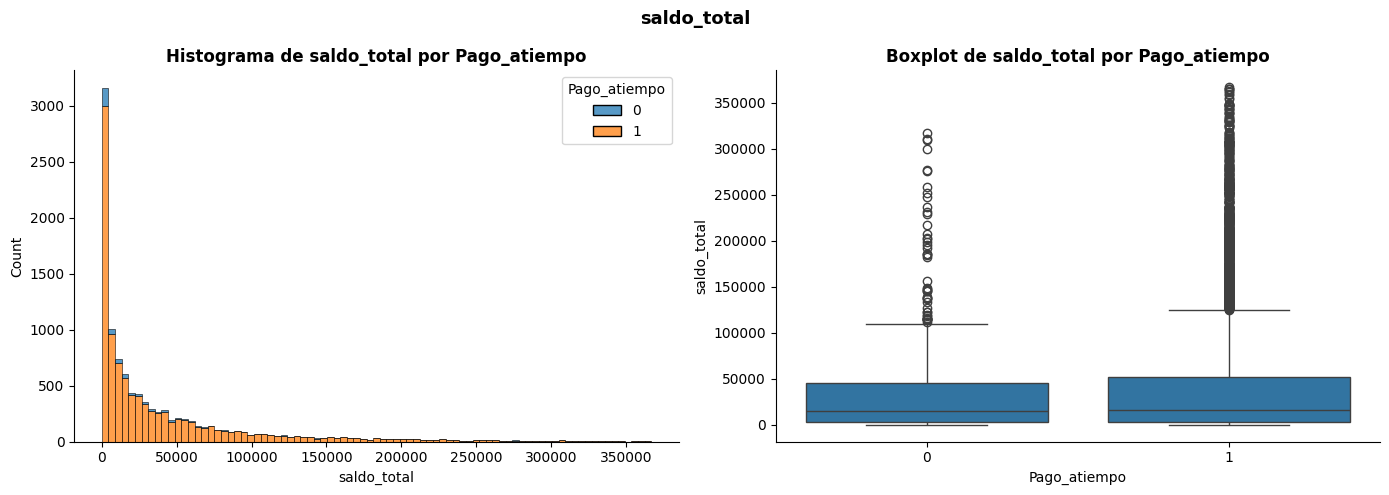

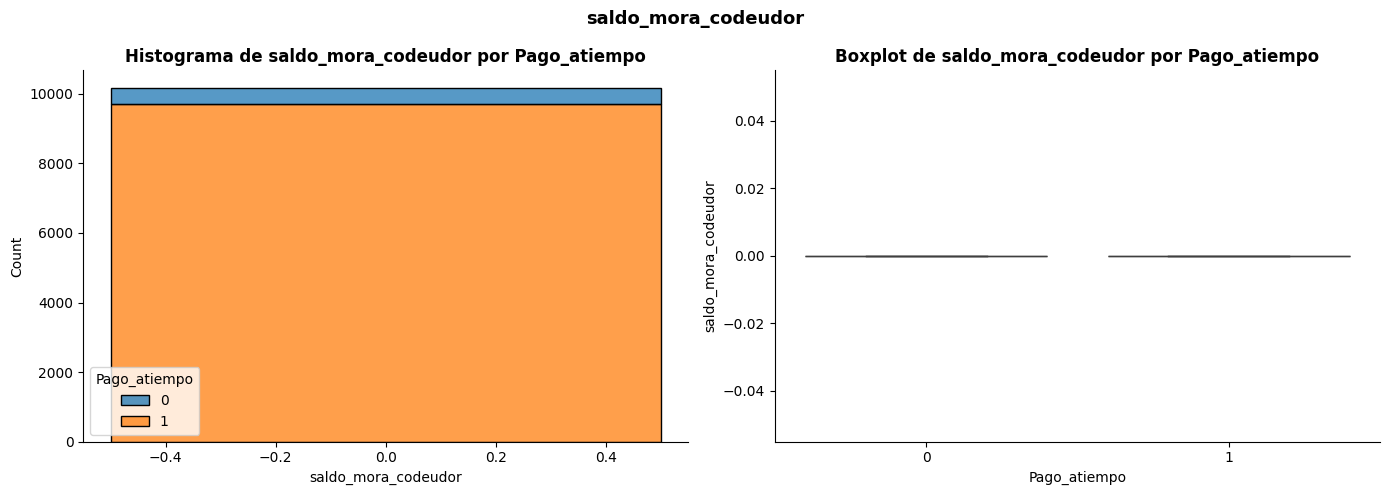

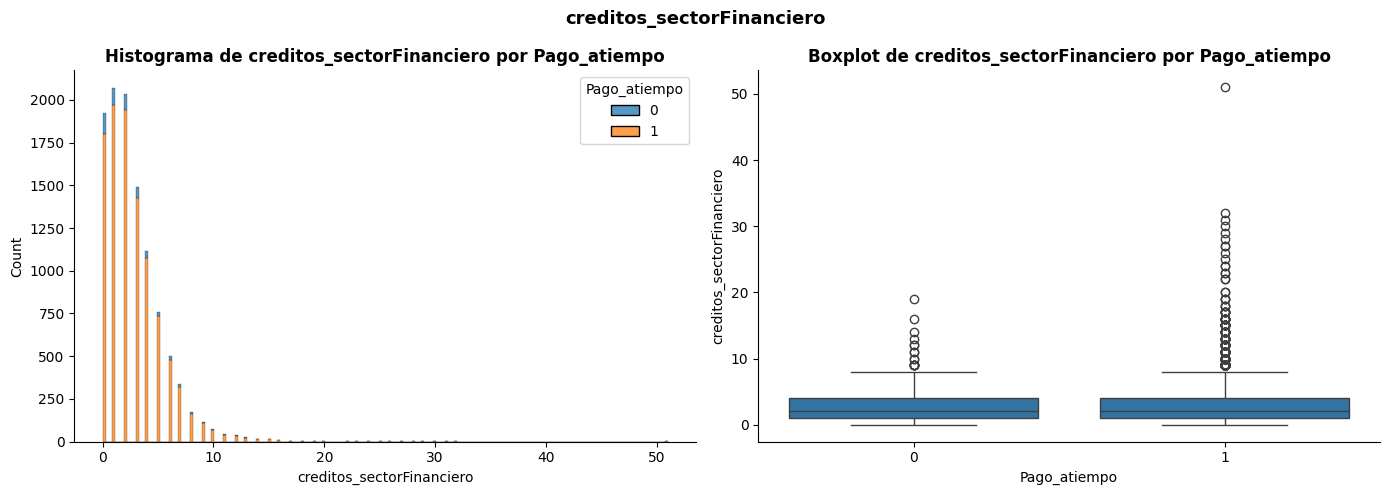

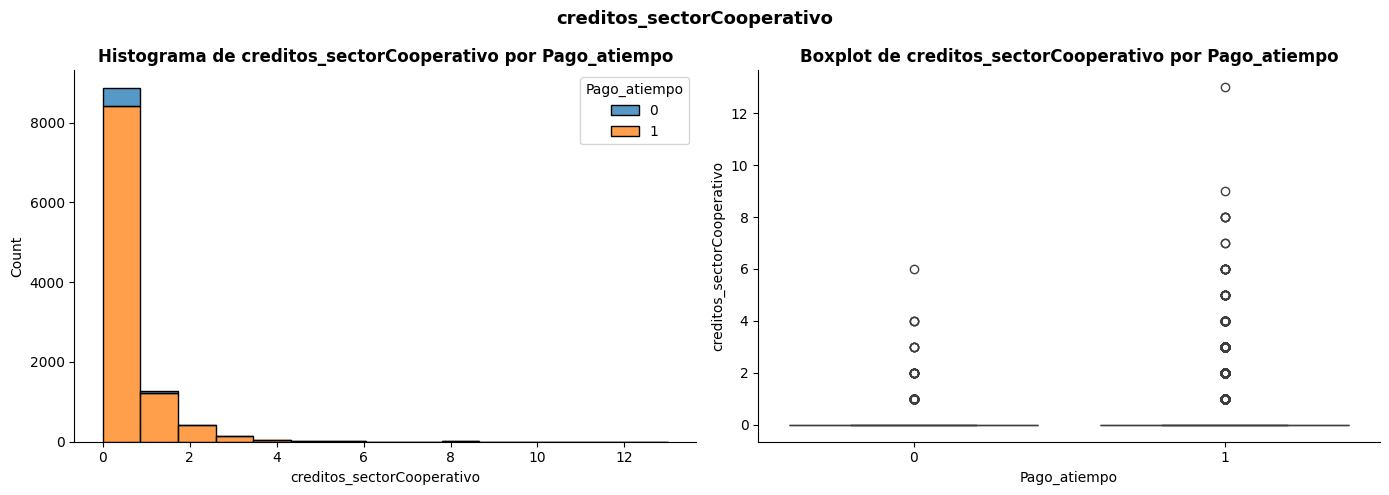

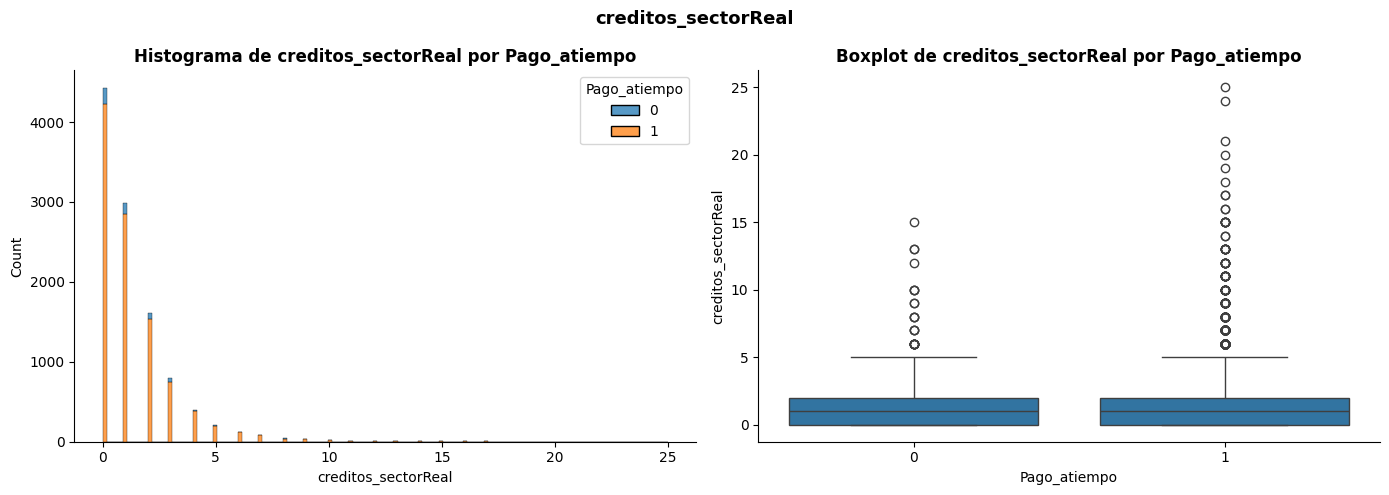

In [30]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'Pago_atiempo']
cat_cols = ['tipo_credito', 'tipo_laboral']

clip_cols = ['salario_cliente', 'total_otros_prestamos', 'saldo_total',
             'saldo_mora', 'saldo_mora_codeudor', 'capital_prestado']

for col in num_cols:
    data = df.copy()
    if col in clip_cols:
        p99 = data[col].quantile(0.99)
        data = data[data[col] <= p99]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(data=data, x=col, hue='Pago_atiempo', kde=False, # Changed kde=True to kde=False
                 multiple='stack', ax=axes[0])
    axes[0].set_title(f'Histograma de {col} por Pago_atiempo', fontweight='bold')
    axes[0].spines[['top', 'right']].set_visible(False)

    sns.boxplot(data=data, x='Pago_atiempo', y=col, ax=axes[1])
    axes[1].set_title(f'Boxplot de {col} por Pago_atiempo', fontweight='bold')
    axes[1].spines[['top', 'right']].set_visible(False)

    plt.suptitle(f'{col}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()



In [31]:
for col in cat_cols:
    print(f"Crosstab de {col} y Pago_atiempo")

    # Tabla de frecuencias absolutas
    tabla_freq = pd.crosstab(df[col], df['Pago_atiempo'])

    # Tabla de porcentajes por fila (normalizar por fila)
    tabla_pct = pd.crosstab(df[col], df['Pago_atiempo'], normalize='index') * 100

    # Combinar ambas en una sola visualización
    print("\nFrecuencias absolutas:")
    display(tabla_freq)

    print("\nPorcentajes por fila (% dentro de cada categoría):")
    display(tabla_pct.round(2))

    print("\n" + "-"*60)

Crosstab de tipo_credito y Pago_atiempo

Frecuencias absolutas:


Pago_atiempo,0,1
tipo_credito,,
4,363,7384
6,9,12
7,0,2
9,136,2740
10,3,113
68,0,1



Porcentajes por fila (% dentro de cada categoría):


Pago_atiempo,0,1
tipo_credito,,
4,4.69,95.31
6,42.86,57.14
7,0.00,100.00
9,4.73,95.27
10,2.59,97.41
68,0.00,100.00



------------------------------------------------------------
Crosstab de tipo_laboral y Pago_atiempo

Frecuencias absolutas:


Pago_atiempo,0,1
tipo_laboral,,
Empleado,290,6464
Independiente,221,3788



Porcentajes por fila (% dentro de cada categoría):


Pago_atiempo,0,1
tipo_laboral,,
Empleado,4.29,95.71
Independiente,5.51,94.49



------------------------------------------------------------


* `capital_prestado`: tanto el histograma como el boxplot muestran que la distribución del  monto prestado es muy similar entre los que pagaron a tiempo (1) y los que no (0). El grupo que no pagó muestra una caja ligeramente más alta, con medianas y percentiles superiores algo mayores.

* `plazo_meses`: la distribución es prácticamente idéntica entre ambos grupos, con medianas similares y los mismos picos en plazos cortos. El plazo del crédito no parece ser un factor diferenciador del incumplimiento.

* `edad_cliente`: los grupos son muy similares aunque el grupo que pagó a tiempo (1) muestra una mediana ligeramente mayor, sugiriendo que clientes más jóvenes tienen una muy leve tendencia a incumplir.

* `salario_cliente`: distribuciones muy parecidas entre grupos, con medianas casi iguales. El salario por sí solo no parace indicar incumplimiento de pago.

* `total_otros_prestamos`: comportamiento similar en ambos grupos. Tener más deuda en otras entidades no parece estar asociado claramente con el incumplimiento en este crédito.

* `puntaje_datacredito`: El grupo que no pagó (0) tiene una caja ligeramente más baja, aunque la diferencia no es tan marcada como se esperaría.

* `huella_consulta`: el grupo que no pagó (0) muestra una mediana y caja ligeramente más altas, lo que indica que los clientes morosos  habían sido consultados más veces. Sin embargo,el grupo que pagó a tiempo (1) tiene numerosos outliers con huellas muy altas (15-29 consultas), lo que indica que una huella elevada no garantiza no pago, pero una huella moderadamente alta aumenta el riesgo.

* `saldo_mora`: los gráficos no se ven bien porque prácticamente todos los valores son 0. Esta variable se podría transformar en una variable binaria (tiene mora / no tiene mora) para que sea más informativa.

* `saldo_total`: el boxplot muestra que el grupo que pagó a tiempo (1) tiene una caja ligeramente más alta que el grupo que no pagó (0), con un Q3 superior. Esto podría explicarse porque quienes cumplen son clientes con más créditos activos y por tanto mayor saldo total vigente.

* `saldo_mora_codeudor`: mismo problema que saldo_mora, casi todos los valores son 0. También podría convertirse a variable binaria.

* `creditos_sectorFinanciero`: distribuciones prácticamente iguales entre grupos.El número de créditos en el sector financiero no diferencia claramente los grupos.

* `creditos_sectorCooperativo`: la mayoría tiene 0 créditos cooperativos en ambos grupos. No se observa diferencia relevante entre quienes pagan y quienes no.

* `creditos_sectorReal`: igual que los anteriores, distribuciones muy similares entre grupos. El número de créditos en el sector real no muestra asociación clara con el incumplimiento.

* `tipo_crediticio`: el tipo 6 llama la atención con una tasa de incumplimiento muy por encima del resto. Sin embargo este tipo solo tiene 21 registros, por lo que no es estadísticamente representativo. Los tipos 4 y 9, que concentran la mayoría de los datos, tienen tasas de incumplimiento muy similares, lo que indica que el tipo de crédito no diferencia bien entre quienes pagan y quienes no.

* `sector_laboral`: los independientes muestran una tasa de incumplimiento ligeramente mayor, lo cual tiene sentido dado que sus ingresos son menos estables. Sin embargo la diferencia no es suficientemente marcada como para considerarla un factor determinante por sí solo.

### **Análisis multivariable**

**¿Los que tienen mora tienen peor puntaje?**

`puntaje_datacredito` vs `saldo_mora`


/tmp/ipython-input-4035677607.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Sin mora', 'Con mora'])


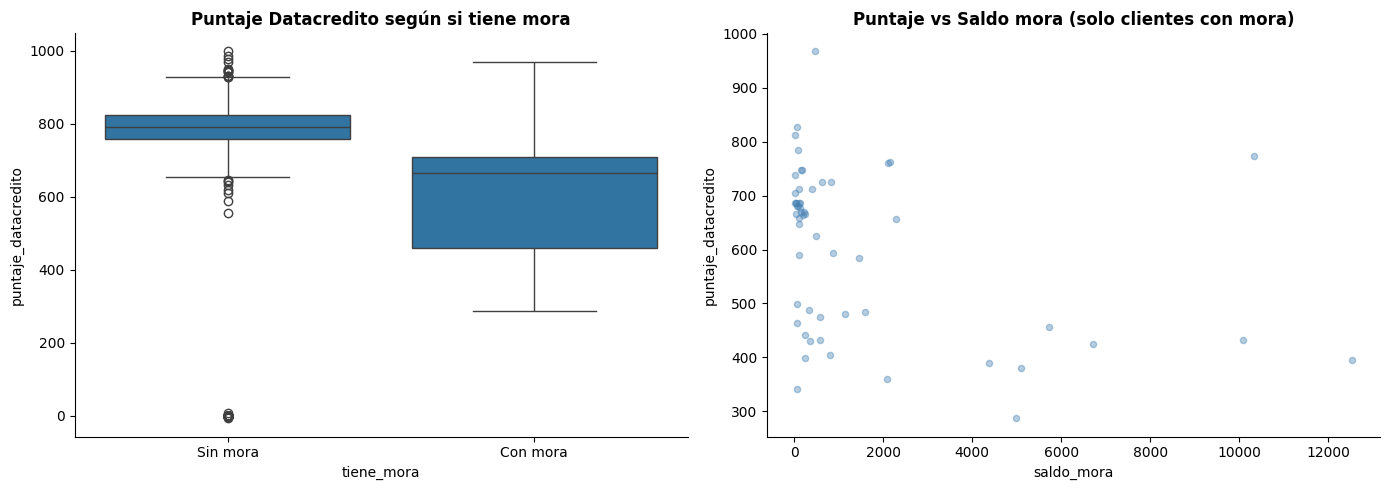

              count   mean    std    min    25%    50%    75%    max
tiene_mora                                                          
0           10702.0  781.7  103.8   -7.0  757.0  791.0  825.0  999.0
1              55.0  602.2  152.1  287.0  460.5  664.0  709.0  968.0


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#boxplot de puntaje por si tiene mora o no
df['tiene_mora'] = (df['saldo_mora'] > 0).astype(int)

sns.boxplot(data=df, x='tiene_mora', y='puntaje_datacredito', ax=axes[0])
axes[0].set_xticklabels(['Sin mora', 'Con mora'])
axes[0].set_title('Puntaje Datacredito según si tiene mora', fontweight='bold')
axes[0].spines[['top', 'right']].set_visible(False)

# scatter solo para los que tienen mora > 0
df_mora = df[df['saldo_mora'] > 0]
axes[1].scatter(df_mora['saldo_mora'], df_mora['puntaje_datacredito'],
                alpha=0.4, color='steelblue', s=20)
axes[1].set_xlabel('saldo_mora')
axes[1].set_ylabel('puntaje_datacredito')
axes[1].set_title('Puntaje vs Saldo mora (solo clientes con mora)', fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# Tabla resumen
print(df.groupby('tiene_mora')['puntaje_datacredito'].describe().round(1))

El boxplot muestra que los clientes sin mora tienen una mediana de puntaje alrededor de 791 con poca dispersión, mientras que los clientes con mora tienen una mediana cercana a 664 y una caja mucho más amplia, lo que indica mayor variabilidad en su historial crediticio.

El scatter de clientes con mora muestra una tendencia negativa leve: a mayor saldo en mora, menor puntaje de Datacredito, aunque con bastante dispersión. Esto valida que el puntaje
de Datacredito captura parcialmente el riesgo de mora, pero no de forma perfecta, ya que
algunos clientes con mora alta aún mantienen puntajes relativamente altos.

**¿Personas con alto puntaje pero muchas consultas pagan peor?**





In [33]:
mediana_puntaje = df['puntaje_datacredito'].median()  # aprox 791
mediana_consulta = df['huella_consulta'].median()      # aprox 4

df['grupo_riesgo'] = 'Otro'
df.loc[(df['puntaje_datacredito'] >= mediana_puntaje) & (df['huella_consulta'] >= mediana_consulta), 'grupo_riesgo'] = 'Score alto + muchas consultas'
df.loc[(df['puntaje_datacredito'] >= mediana_puntaje) & (df['huella_consulta'] < mediana_consulta), 'grupo_riesgo'] = 'Score alto + pocas consultas'
df.loc[(df['puntaje_datacredito'] < mediana_puntaje) & (df['huella_consulta'] >= mediana_consulta), 'grupo_riesgo'] = 'Score bajo + muchas consultas'
df.loc[(df['puntaje_datacredito'] < mediana_puntaje) & (df['huella_consulta'] < mediana_consulta), 'grupo_riesgo'] = 'Score bajo + pocas consultas'

/tmp/ipython-input-2519075773.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conteo = df.groupby(['grupo_riesgo', 'Pago_atiempo']).size().unstack()


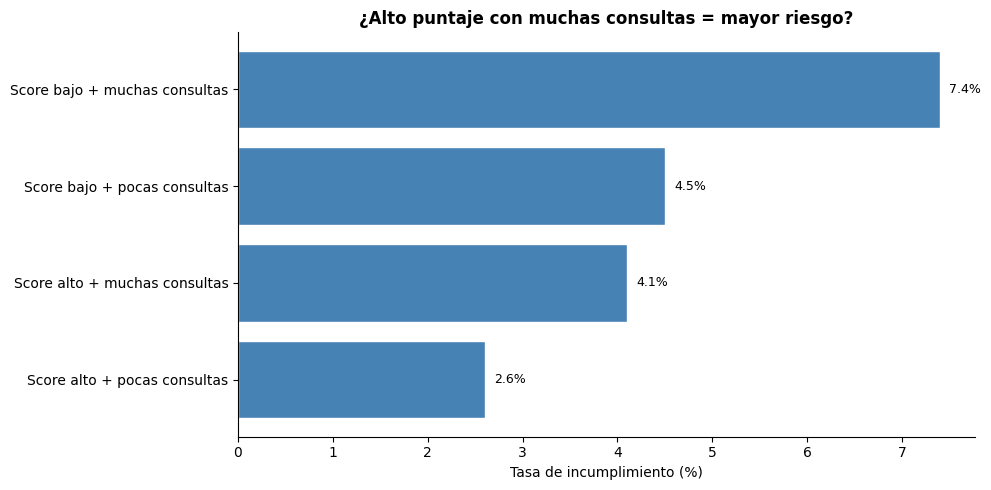

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))

conteo = df.groupby(['grupo_riesgo', 'Pago_atiempo']).size().unstack()
conteo.columns = ['No pagó', 'Pagó a tiempo']
conteo['tasa'] = (conteo['No pagó'] / (conteo['No pagó'] + conteo['Pagó a tiempo']) * 100).round(1)
conteo = conteo[conteo.index != 'Otro']  # excluir Otro si existe

tasa = conteo['tasa'].sort_values()

bars = ax.barh(tasa.index, tasa.values, color='steelblue', edgecolor='white')

for bar, val in zip(bars, tasa.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9)

ax.set_xlabel('Tasa de incumplimiento (%)')
ax.set_title('¿Alto puntaje con muchas consultas = mayor riesgo?', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Previamente se identificó que existen clientes que pagan a tiempo aun cuando presentan un número elevado de consultas crediticias, entonces acá se analiza eso en conjunto con su puntaje.

En general, los clientes con menor puntaje presentan una mayor probabilidad de incumplimiento, lo cual es esperado. Sin embargo, el número de consultas parece agravar el riesgo de manera independiente al score. Específicamente, dentro del grupo de puntaje bajo, aquellos con alta cantidad de consultas presentan casi el doble de riesgo en comparación con quienes tienen puntaje bajo pero pocas consultas. Este mismo comportamiento se replica en clientes con puntaje alto: un mayor número de consultas incrementa la probabilidad de incumplimiento incluso en perfiles aparentemente sólidos.

**¿Clientes con créditos en los 3 sectores simultáneamente incumplen más?**





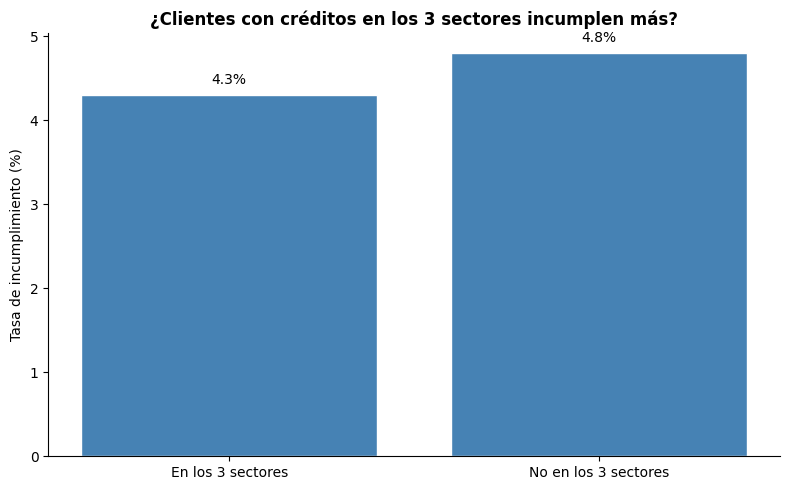

                      total  no_pago  tasa
en_3_sectores                             
En los 3 sectores       962       41   4.3
No en los 3 sectores   9801      470   4.8


In [35]:
fig, ax = plt.subplots(figsize=(8, 5))

#Se crea variablle según si tiene crédito en todos los sectores o no
df['en_3_sectores'] = (
    (df['creditos_sectorFinanciero'] > 0) &
    (df['creditos_sectorCooperativo'] > 0) &
    (df['creditos_sectorReal'] > 0)
).map({True: 'En los 3 sectores', False: 'No en los 3 sectores'})

tasa = df.groupby('en_3_sectores')['Pago_atiempo'].apply(
    lambda x: (x == 0).sum() / len(x) * 100
).round(1).reset_index()
tasa.columns = ['grupo', 'tasa']

bars = ax.bar(tasa['grupo'], tasa['tasa'], color='steelblue', edgecolor='white')

for bar, val in zip(bars, tasa['tasa']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val}%', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Tasa de incumplimiento (%)')
ax.set_title('¿Clientes con créditos en los 3 sectores incumplen más?', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print(df.groupby('en_3_sectores')['Pago_atiempo'].agg(
    total='count',
    no_pago=lambda x: (x==0).sum()
).assign(tasa=lambda x: (x['no_pago']/x['total']*100).round(1)))

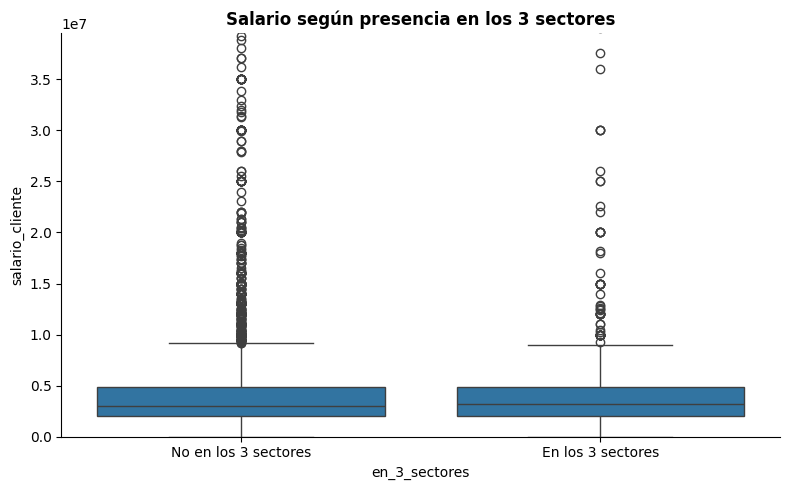

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=df, x='en_3_sectores', y='salario_cliente', ax=ax)
p99 = df['salario_cliente'].quantile(0.99)
ax.set_ylim(0, p99)
ax.set_title('Salario según presencia en los 3 sectores', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Contrario a lo esperado, los clientes con créditos en los 3 sectores simultáneamente tienen
una tasa de incumplimiento ligeramente menor (4.3%) que los que no están en los 3 sectores
(4.8%). La diferencia es mínima y sugiere que tener créditos en múltiples sectores no es necesariamente una señal de mayor riesgo.

Se analizó si la presencia de créditos en todos los sectores estaba asociada a un mayor nivel salarial. Pero como se observa en el boxplot, no se evidencian diferencias significativas, por lo que podría estar más relacionada con la experiencia crediticia del cliente o factores externos.

`puntaje_datacredito` vs `saldo_total` por `pago_atiempo`



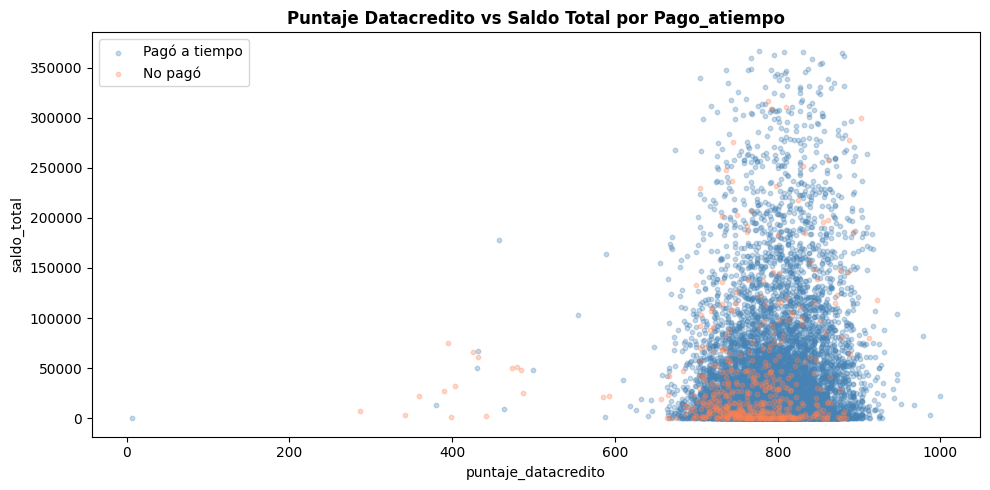

In [38]:
p99_sal = df['saldo_total'].quantile(0.99)
df_plot = df[df['saldo_total'] <= p99_sal]

plt.figure(figsize=(10, 5))
for val, color, label in [(1, 'steelblue', 'Pagó a tiempo'), (0, 'coral', 'No pagó')]:
    subset = df_plot[df_plot['Pago_atiempo'] == val]
    plt.scatter(subset['puntaje_datacredito'], subset['saldo_total'],
                alpha=0.3, s=10, color=color, label=label)
plt.xlabel('puntaje_datacredito')
plt.ylabel('saldo_total')
plt.title('Puntaje Datacredito vs Saldo Total por Pago_atiempo', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

Los puntos naranjas (no pagaron) aparecen dispersos en toda la zona de puntajes bajos (0-650), mientras que en la zona de puntajes altos (700-950) donde se concentra la mayoría, los naranjas están completamente mezclados con los azules y no se distinguen. Esto confirma que puntajes bajos son una señal clara de riesgo, pero puntajes altos no  garantizan buen pago. El saldo total no parece añadir información adicional para separar los grupos.

**¿Los independientes con bajo puntaje son el grupo más riesgoso?**

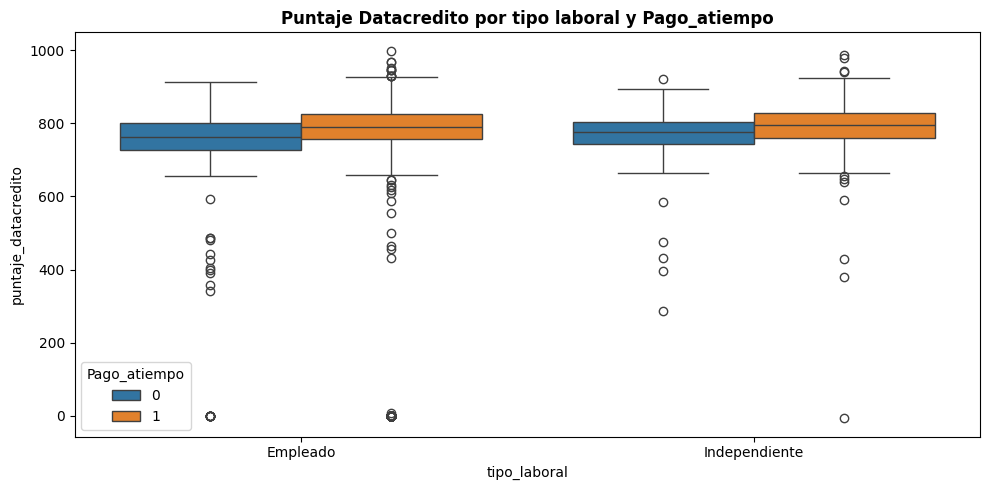

In [39]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='tipo_laboral', y='puntaje_datacredito', hue='Pago_atiempo')
plt.title('Puntaje Datacredito por tipo laboral y Pago_atiempo', fontweight='bold')
plt.tight_layout()
plt.show()

El patrón es prácticamente idéntico entre empleados
  e independientes. En ambos grupos, los que no pagaron (0) tienen una caja ligeramente
  más baja que los que sí pagaron (1), pero la diferencia es muy pequeña y las cajas se
  solapan casi completamente. Esto indica que el tipo laboral no modifica significativamente
  la relación entre puntaje y pago, el score discrimina igual de mal (o igual de bien)
  para empleados e independientes.

**¿Se piden montos distintos según el tipo de empleo?**

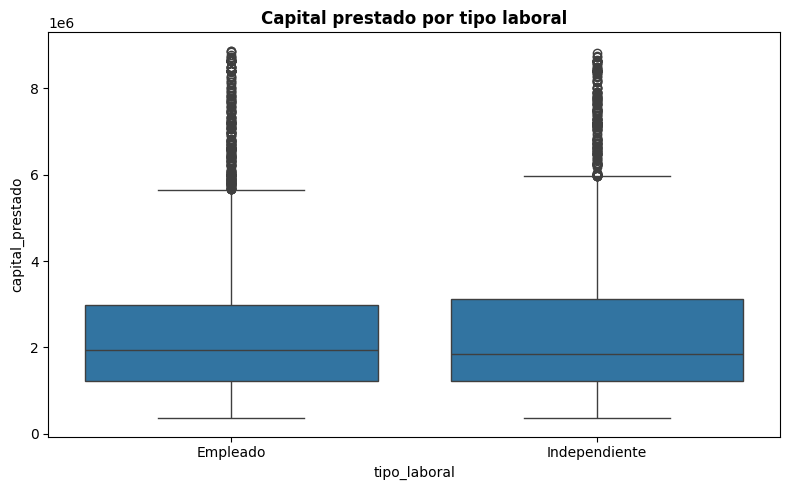

In [40]:
p99 = df['capital_prestado'].quantile(0.99)
df_plot = df[df['capital_prestado'] <= p99]

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_plot, x='tipo_laboral', y='capital_prestado')
plt.title('Capital prestado por tipo laboral', fontweight='bold')
plt.tight_layout()
plt.show()

Las cajas son prácticamente idénticas entre empleados
  e independientes, con medianas muy similares (~1.9M) y rangos intercuartílicos casi
  iguales. Los independientes no piden montos significativamente distintos a los empleados.
  El tipo laboral no parece influir en el monto solicitado.

**¿Cómo es la relación de la edad con el capital pedido? ¿Entre más jovenes hay más posibilidad de no pago?**



/tmp/ipython-input-3391011950.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = df.groupby(['grupo_edad', 'tamaño_credito'])['Pago_atiempo'].apply(lambda x: (x==0).mean()*100).unstack()


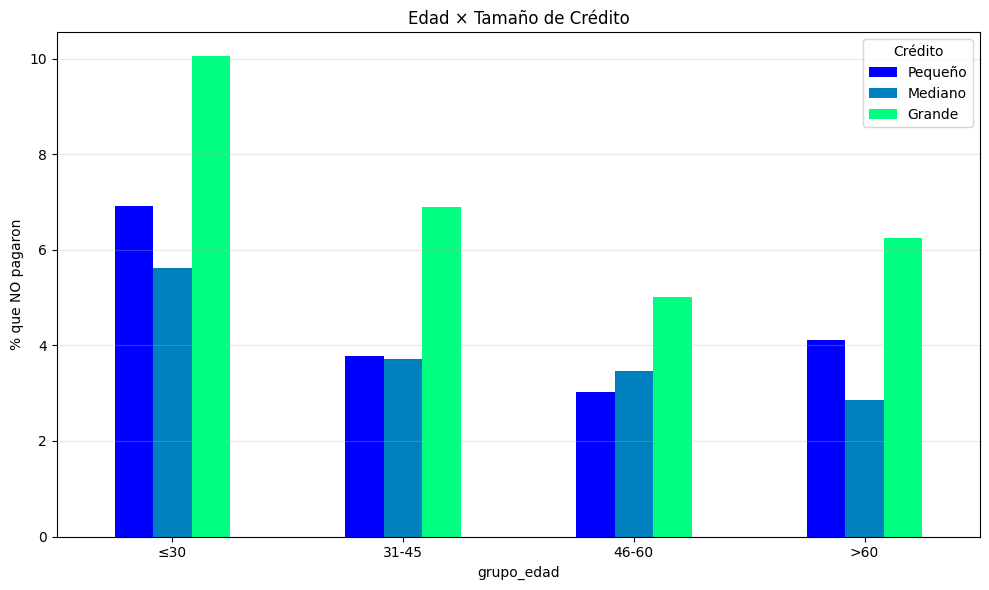

In [61]:
# Categorizar por grupo edad y tamaño de crédito (se crean bins)
df['grupo_edad'] = pd.cut(df['edad_cliente'], bins=[0, 30, 45, 60, 150],
                          labels=['≤30', '31-45', '46-60', '>60'])
df['tamaño_credito'] = pd.cut(df['capital_prestado'], bins=[0, 1_500_000, 3_000_000, float('inf')],
                               labels=['Pequeño', 'Mediano', 'Grande'])

# Calcular tasas
pivot = df.groupby(['grupo_edad', 'tamaño_credito'])['Pago_atiempo'].apply(lambda x: (x==0).mean()*100).unstack()

# GRÁFICO
pivot.plot(kind='bar', figsize=(10, 6), rot=0, colormap="winter")
plt.ylabel('% que NO pagaron')
plt.title('Edad × Tamaño de Crédito')
plt.legend(title='Crédito')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
pivot

tamaño_credito,Pequeño,Mediano,Grande
grupo_edad,,,
≤30,6.920904,5.624143,10.046729
31-45,3.774834,3.722504,6.899166
46-60,3.015075,3.456998,5.006418
>60,4.106280,2.863962,6.250000


Los clientes jóvenes (≤30 años) que solicitan créditos grandes
(>$3M) presentan una tasa de incumplimiento del 10%, más del doble del promedio general
(4.75%).

Los créditos grandes muestran mayor incumplimiento en todos los
grupos, confirmando que el monto del compromiso financiero es un factor de riesgo
independiente.

**¿Huella según tipo laboral? ¿Afecta el pago?**

/tmp/ipython-input-2266444734.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = df.groupby(['tipo_laboral', 'huella_cat'])['Pago_atiempo'].apply(lambda x: (x==0).mean()*100).unstack()


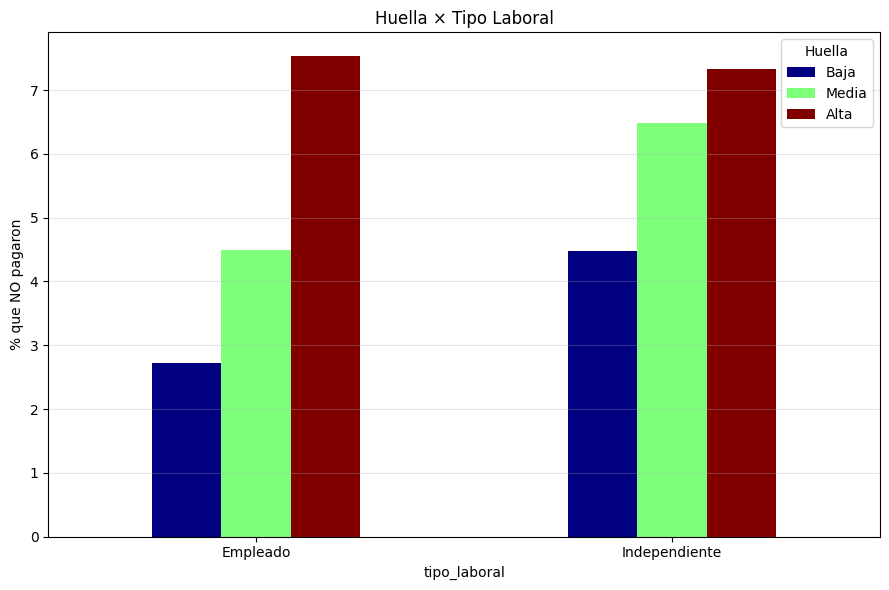

In [64]:
# Categorizar huella
df['huella_cat'] = pd.cut(df['huella_consulta'], bins=[0, 3, 6, float('inf')],
                          labels=['Baja', 'Media', 'Alta'])

# Calcular tasas
pivot = df.groupby(['tipo_laboral', 'huella_cat'])['Pago_atiempo'].apply(lambda x: (x==0).mean()*100).unstack()

# GRÁFICO
pivot.plot(kind='bar', figsize=(9, 6), rot=0, colormap='jet')
plt.ylabel('% que NO pagaron')
plt.title('Huella × Tipo Laboral')
plt.legend(title='Huella')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

La huella alta es igualmente peligrosa para
ambos grupos, elevando el riesgo a aproximadamente 7.5% independientemente del tipo laboral. Esto confirma
que una huella alta es una señal universal de riesgo.

También puede verse que los trabajadores independientes con huella baja, ya igualan a empleados con huella media, por lo que podría decirse que los independientes presentan una base de riesgo más elevada en todos los niveles.

**¿Edad y Tipo Laboral?**

/tmp/ipython-input-306433647.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = df.groupby(['grupo_edad', 'tipo_laboral'])['Pago_atiempo'].apply(lambda x: (x==0).mean()*100).unstack()


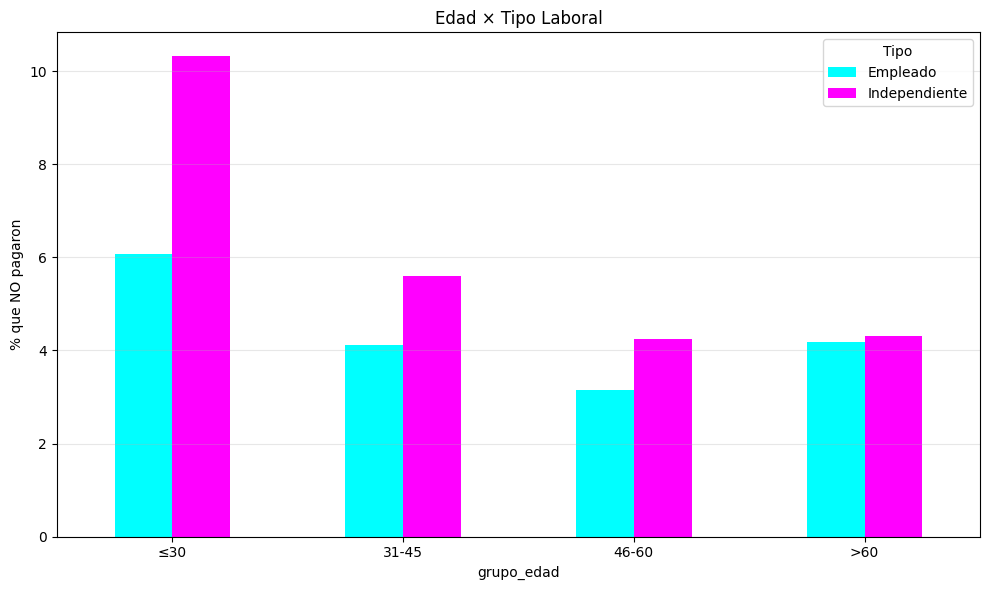

In [73]:
# Calcular tasas
pivot = df.groupby(['grupo_edad', 'tipo_laboral'])['Pago_atiempo'].apply(lambda x: (x==0).mean()*100).unstack()

# GRÁFICO
pivot.plot(kind='bar', figsize=(10, 6), rot=0, colormap='cool')
plt.ylabel('% que NO pagaron')
plt.title('Edad × Tipo Laboral')
plt.legend(title='Tipo')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [45]:
pivot

tipo_laboral,Empleado,Independiente
grupo_edad,,
≤30,6.071429,10.322581
31-45,4.121622,5.602923
46-60,3.149606,4.244032
>60,4.172275,4.314721


El gráfico muestra que la combinación edad joven + independiente representa el grupo de mayor riesgo: los independientes menores de 30 años alcanzan una tasa de incumplimiento del 10.3%, casi el doble que los empleados del mismo rango (6.1%).

A medida que aumenta la edad, el riesgo disminuye en ambos grupos y la brecha entre empleados e independientes se va cerrando progresivamente.



**Ratio de Capital Salario**

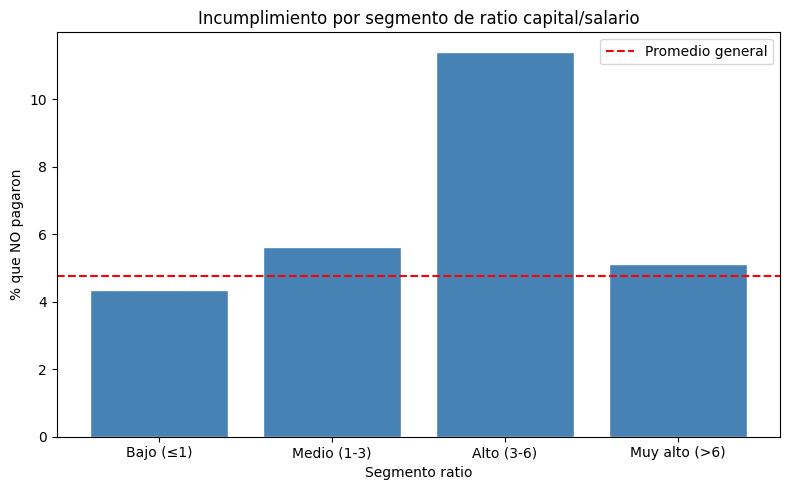

In [54]:
#Se calcula el ratio
df['ratio_capital_salario'] = df['capital_prestado'] / df['salario_cliente']

#Se crean los bins (1 es que pidió lo mismo que gana)
bins = [0, 1, 3, 6, df['ratio_capital_salario'].max()]
labels = ['Bajo (≤1)', 'Medio (1-3)', 'Alto (3-6)', 'Muy alto (>6)']
df['segmento_ratio'] = pd.cut(df['ratio_capital_salario'], bins=bins, labels=labels)

tasa_ratio = df.groupby('segmento_ratio', observed=True)['Pago_atiempo'].apply(
    lambda x: (x == 0).mean() * 100
).reset_index()
tasa_ratio.columns = ['segmento_ratio', 'pct_no_pago']

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.bar(tasa_ratio['segmento_ratio'], tasa_ratio['pct_no_pago'], color='steelblue', edgecolor='white')
ax.axhline(y=df['Pago_atiempo'].eq(0).mean()*100, color='red', linestyle='--', label='Promedio general')
ax.set_title('Incumplimiento por segmento de ratio capital/salario')
ax.set_xlabel('Segmento ratio')
ax.set_ylabel('% que NO pagaron')
ax.legend()

plt.tight_layout()
plt.show()


In [55]:
df['Pago_atiempo'].eq(0).mean()*100

np.float64(4.7477469107126264)

Los clientes con ratio Bajo se mantienen por debajo del promedio general con, y el segmento Medio lo supera por poco. Sin embargo, el segmento Alto dispara la tasa a más del doble del promedio general, siendo la zona de mayor riesgo identificada con esta variable.

El segmento Muy alto baja nuevamente a aproximadamente 5%, lo cual parece contradictorio pero probablemente se explica por el bajo volumen de registros en ese rango y por un posible sesgo de selección: los clientes a quienes se aprueba un crédito tan alto respecto a su salario posiblemente pasaron filtros adicionales.